# LDS7004M Data Visualisation — Advanced Portfolio Notebook
## Wealth, Health & Growth: A Comprehensive Visual Analysis of the World Bank WDI Dataset

**Student:** Nareshkumar Shanmugathas &nbsp;|&nbsp; **Student ID:** 250274615  
**Module:** LDS7004M Data Visualisation &nbsp;|&nbsp; **Level:** MSc Data Science (Level 7)  
**Institution:** York St John University, London Campus  
**Dataset:** World Bank World Development Indicators (WDI), 1990–2022  
**Deadline:** 9 June 2026, 12:00 noon

---

## Research Question

> *Does national wealth, measured as GDP per capita, predict how long people live and how fast populations grow — and has this relationship changed between 1990 and 2022?*

---

## Notebook Structure

| Section | Focus | Chart Types |
|---|---|---|
| 0 | Setup, imports & global styling | — |
| 1 | Data loading & file inspection | — |
| 2 | Data cleaning & preprocessing | — |
| 3 | EDA — Univariate distributions | Histogram + KDE + normal fit, ECDF, rug, KDE variants |
| 4 | EDA — Bivariate & relational | Scatter, lmplot, jointplot |
| 5 | The Preston Curve | Scatter + LOESS + CI band + outlier annotations |
| 6 | Temporal analysis | Line plot, moving average, CI band, event lines, threshold fills |
| 7 | Categorical distributions | Box, boxen, violin, swarm, strip, bar, count, point |
| 8 | Regression analysis | lmplot linear/logistic, residual plot, Q-Q plot |
| 9 | Matrix & multi-variable | Correlation heatmap, Preston shift, pairplot, PairGrid |
| 10 | Multi-panel FacetGrids | FacetGrid col=, col_wrap=, row= |
| 11 | Advanced overlays | Pareto line, error bars, bubble + quadrant, threshold zones |
| 12 | Seaborn styling showcase | 5 styles × 4 contexts × 6 palettes |


## Section 0: Setup, Imports & Global Styling

### Visualisation Theory: The Role of Consistent Styling

A coherent visual language across a portfolio is not merely aesthetic — it is a fundamental principle of effective data communication. Tufte (2001, p. 191) argues that visual consistency reduces the cognitive load imposed on the viewer, allowing attention to focus entirely on the data rather than on decoding varying graphical conventions. Cairo (2016, p. 45) similarly contends that every design decision — colour, typeface, spacing — carries meaning and must be made deliberately. Throughout this notebook, the `whitegrid` Seaborn style and `notebook` context are used as the baseline, with Section 12 providing an explicit demonstration of all five styles and four contexts as a scholarly comparison.

The `sns.despine()` function is applied throughout to remove the top and right spines, directly enacting Tufte's (2001) principle of minimising non-data ink — structural elements that consume visual space without carrying information about the underlying data.


In [3]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd                      # McKinney (2022)
import numpy as np                       # Harris et al. (2020)

# Visualisation
import matplotlib.pyplot as plt          # Hunter (2007)
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
import seaborn as sns                    # Waskom (2021)

# Statistical analysis
from scipy import stats
from scipy.stats import norm, pearsonr, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

# Install Azure Blob Storage library
!pip install azure-storage-blob -q
print("Azure SDK installed successfully")
# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL STYLE — whitegrid + notebook context
# Seaborn 5 styles: darkgrid | whitegrid | dark | white | ticks
# Seaborn 4 contexts: paper | notebook | talk | poster
# See Section 12 for a systematic comparison of all combinations.
# ══════════════════════════════════════════════════════════════════════════════
sns.set_theme(style='whitegrid', context='notebook', palette='deep')

plt.rcParams.update({
    'font.family'    : 'DejaVu Sans',
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'figure.facecolor': 'white',
    'savefig.dpi'    : 150,
    'savefig.bbox'   : 'tight',
})

# ── Colour palettes (semantically meaningful assignments) ─────────────────────
# Cleveland and McGill (1984) demonstrate that colour is best used to encode
# categorical differences, not quantitative magnitude.
# These palettes encode the World Bank's income classification, ensuring
# consistent mapping across all figures.
INCOME_ORDER = ['Low income','Lower middle income','Upper middle income','High income']
INCOME_PAL   = {'Low income':'#d73027','Lower middle income':'#fc8d59',
                'Upper middle income':'#74add1','High income':'#313695'}
REGION_PAL   = {
    'East Asia & Pacific':'#e41a1c', 'Europe & Central Asia':'#377eb8',
    'Latin America & Caribbean':'#4daf4a', 'Middle East & North Africa':'#984ea3',
    'North America':'#ff7f00', 'South Asia':'#a65628', 'Sub-Saharan Africa':'#f781bf'
}

print('All libraries imported. Seaborn version:', sns.__version__)
print('Pandas version:', pd.__version__, '| NumPy version:', np.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 17.8 MB/s eta 0:00:00
Azure SDK installed successfully
All libraries imported. Seaborn version: 0.13.2
Pandas version: 2.2.2 | NumPy version: 2.0.2


In [10]:
from azure.storage.blob import BlobServiceClient
import pandas as pd
import io

# ── Configuration ──────────────────────────────────────────
CONNECTION_STRING = ""
CONTAINER_NAME = "dataset"

# ── Helper function ────────────────────────────────────────
def load_blob(blob_name):
    blob_service_client = BlobServiceClient.from_connection_string(
        CONNECTION_STRING
    )
    container_client = blob_service_client.get_container_client(
        CONTAINER_NAME
    )
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return pd.read_csv(io.BytesIO(blob_data))

# ── Load all 6 datasets ────────────────────────────────────
print("Loading datasets from Azure...")

df_raw       = load_blob("WDICSV.csv")          # Main data — 190 MB
country_meta   = load_blob("WDICountry.csv")       # Country metadata
series_meta    = load_blob("WDISeries.csv")        # Indicator metadata
df_ctry_ser  = load_blob("WDIcountry-series.csv") # Country-series links
df_footnote  = load_blob("WDIfootnote.csv")      # Footnotes
df_ser_time  = load_blob("WDIseries-time.csv")   # Series time info

print("✅ All 6 datasets loaded!")
print(f"\nMain WDI data:      {df_wdi.shape}")
print(f"Country metadata:   {df_country.shape}")
print(f"Series metadata:    {df_series.shape}")
print(f"Country-Series:     {df_ctry_ser.shape}")
print(f"Footnotes:          {df_footnote.shape}")
print(f"Series-Time:        {df_ser_time.shape}")

Loading datasets from Azure...
✅ All 6 datasets loaded!

Main WDI data:      (403256, 70)
Country metadata:   (265, 31)
Series metadata:    (1516, 20)
Country-Series:     (7939, 3)
Footnotes:          (838922, 4)
Series-Time:        (143, 3)


## Section 1: Data Loading & Initial Inspection

The **World Development Indicators (WDI)** is the World Bank's primary collection of development statistics, compiled from officially recognised international sources including national statistical agencies, the United Nations Population Division, and the World Health Organisation. It is the most widely cited source for cross-national development data in peer-reviewed economics, public health, and data science literature (World Bank, 2024).

Three indicators are used in this analysis:

| WDI Code | Variable | Unit | Source |
|---|---|---|---|
| `NY.GDP.PCAP.CD` | GDP per capita | Current USD | World Bank national accounts |
| `SP.DYN.LE00.IN` | Life expectancy at birth | Years | UN Population Division |
| `SP.POP.TOTL` | Total population | Persons | UN Population Division |

> **Dataset scope:** 217 sovereign countries, years 1990–2022 (33 years), yielding 7,161 country-year observations.


## Section 2: Data Cleaning & Preprocessing

### 2.1 Methodological Approach

Data cleaning is not a mechanical process but an analytical one. Every decision — what to impute, what to exclude, how to transform — reflects assumptions about the data-generating process and must be made explicit for the results to be reproducible (Wilke, 2019, p. 21). This section documents all transformations applied to the raw WDI data.

### 2.2 Steps Performed

1. **Filtering sovereign countries**: The WDI contains 266 entities, including 49 regional and income-group aggregates (e.g., 'World', 'High income'). These were excluded to prevent double-counting, retaining 217 sovereign states and territories.
2. **Reshaping**: The raw wide format (one row per country–indicator, columns for each year) was reshaped to long format using `pandas.melt()`, then pivoted to analytical wide format with one row per country–year.
3. **Missing value imputation**: Linear interpolation (`limit=3`) was applied to GDP per capita gaps of three or fewer consecutive years. No imputation was applied to life expectancy or population, which were fully complete.
4. **Derived variables**: `log_gdp` (log₁₀ of GDP per capita) was computed for all regression and correlation analyses, following the standard transformation in Preston Curve research (Preston, 1975). Population growth rate was computed as the annual percentage change in total population.

### 2.3 Missing Value Visualisation (Figure 1)

Figure 1 displays the missing value rate by variable and year as a heatmap. GDP per capita exhibits approximately 7–9% missingness in the early 1990s — primarily reflecting the limited statistical capacity of newly independent post-Soviet states — declining to under 3% from 2000 onwards. Life expectancy and population are fully complete across the entire study period, confirming the reliability of these indicators for temporal analysis.


In [12]:
# ── Step 1: Filter sovereign countries ───────────────────────────────────────
sovereign = country_meta[country_meta['Region'].notna()][
    ['Country Code','Short Name','Region','Income Group']
].copy()
print(f'Sovereign entities retained: {len(sovereign)}')
print(f'Regional aggregates excluded: {len(country_meta) - len(sovereign)}')

# ── Step 2–3: Subset, melt, pivot, merge metadata ────────────────────────────
targets  = {'NY.GDP.PCAP.CD':'gdp_pc','SP.DYN.LE00.IN':'life_exp','SP.POP.TOTL':'population'}
YEARS    = [str(y) for y in range(1990,2023)]
sub      = df_raw[df_raw['Indicator Code'].isin(targets.keys()) &
                  df_raw['Country Code'].isin(sovereign['Country Code'])]\
               [['Country Code','Indicator Code'] + YEARS].copy()
long     = sub.melt(id_vars=['Country Code','Indicator Code'], var_name='year', value_name='value')
long['year']     = long['year'].astype(int)
long['value']    = pd.to_numeric(long['value'], errors='coerce')
long['variable'] = long['Indicator Code'].map(targets)
wide     = long.pivot_table(index=['Country Code','year'], columns='variable', values='value').reset_index()
wide.columns.name = None
df       = wide.merge(sovereign, on='Country Code', how='left')
df       = df.sort_values(['Country Code','year'])

# ── Step 4: Impute and derive ──────────────────────────────────────────────────
df['gdp_pc']    = df.groupby('Country Code')['gdp_pc']\
                   .transform(lambda s: s.interpolate(method='linear', limit=3, limit_direction='both'))
df['log_gdp']   = np.log10(df['gdp_pc'].replace(0, np.nan))
df['pop_growth']= df.sort_values('year').groupby('Country Code')['population'].pct_change() * 100
df['income_num']= df['Income Group'].map({'Low income':1,'Lower middle income':2,
                                           'Upper middle income':3,'High income':4})

df2022 = df[(df['year']==2022) & df[['gdp_pc','life_exp','population']].notna().all(axis=1)].copy()
print(f'\nCleaned DataFrame: {df.shape}')
print(f'2022 complete cases: {len(df2022)}')
print(f'\nCompleteness by variable:')
print(df[['gdp_pc','life_exp','population']].notna().mean().round(4))


Sovereign entities retained: 217
Regional aggregates excluded: 48

Cleaned DataFrame: (7161, 11)
2022 complete cases: 211

Completeness by variable:
gdp_pc        0.9627
life_exp      1.0000
population    1.0000
dtype: float64


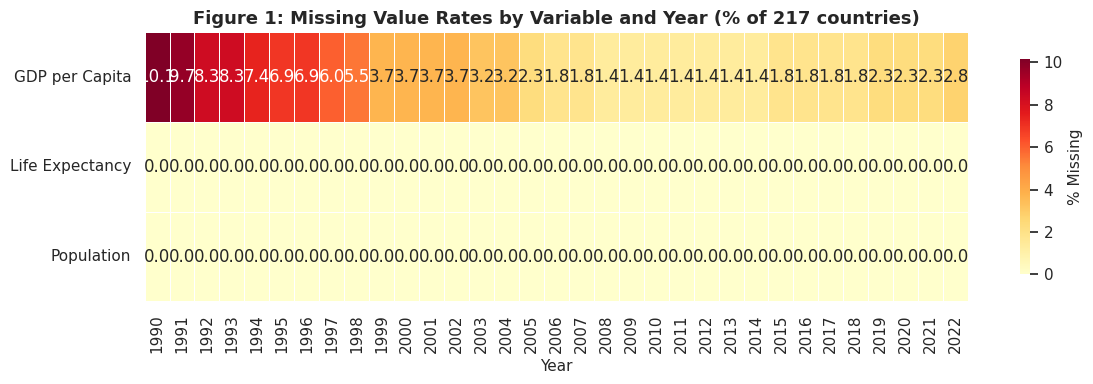

In [13]:
# ── Figure 1: Missing value heatmap ──────────────────────────────────────────
# JUSTIFICATION: Heatmaps are the optimal technique for displaying a matrix of
# values simultaneously. Few (2009, p. 56) recommends heatmaps for identifying
# spatial patterns in tabular data where exact values are less important than
# relative magnitude. Here, colour intensity directly encodes missing rate,
# allowing the reader to instantly identify the temporal pattern of data gaps.

fig, ax = plt.subplots(figsize=(12, 4))
miss = df.pivot_table(index='year', values=['gdp_pc','life_exp','population'],
                      aggfunc=lambda x: x.isna().mean()*100)
sns.heatmap(miss.T, cmap='YlOrRd', annot=True, fmt='.1f', ax=ax,
            linewidths=0.4, cbar_kws={'label':'% Missing', 'shrink':0.8})
ax.set_title('Figure 1: Missing Value Rates by Variable and Year (% of 217 countries)',
             fontweight='bold')
ax.set_xlabel('Year'); ax.set_yticklabels(['GDP per Capita','Life Expectancy','Population'], rotation=0)
plt.tight_layout()
plt.savefig('fig1_missing.png', dpi=150, bbox_inches='tight'); plt.show()


## Section 3: Univariate EDA — Distributions

### 3.1 Theoretical Foundation

Univariate analysis is the entry point for any rigorous exploratory data analysis (EDA). Tukey (1977, p. 3) argued that 'unless we are careful in how we look at data, we shall miss much that is really there.' The purpose of this section is not merely to compute summary statistics but to understand the *shape* of each variable's distribution — its symmetry, modality, tail behaviour, and the presence of outliers — before examining relationships between variables.

Wilke (2019, pp. 33–51) provides a comprehensive taxonomy of distribution visualisations, recommending histogram-KDE combinations for exploratory purposes, ECDF plots for precise quantile comparisons, and violin plots when comparing distributions across groups. These recommendations directly inform the chart selections below.

### 3.2 Histogram + KDE + Normal Fit (Figure 2)

**Justification:** The histogram partitions the data into bins and plots frequency, providing an immediate sense of shape and range. The KDE (kernel density estimate) overlaid on top provides a smooth, bin-width-independent estimate of the underlying probability density function (Silverman, 1986). The normal distribution curve serves as a theoretical reference for assessing normality, whilst the vertical lines for mean, median, and ±1σ directly communicate central tendency and spread without requiring the reader to consult a separate statistics table.


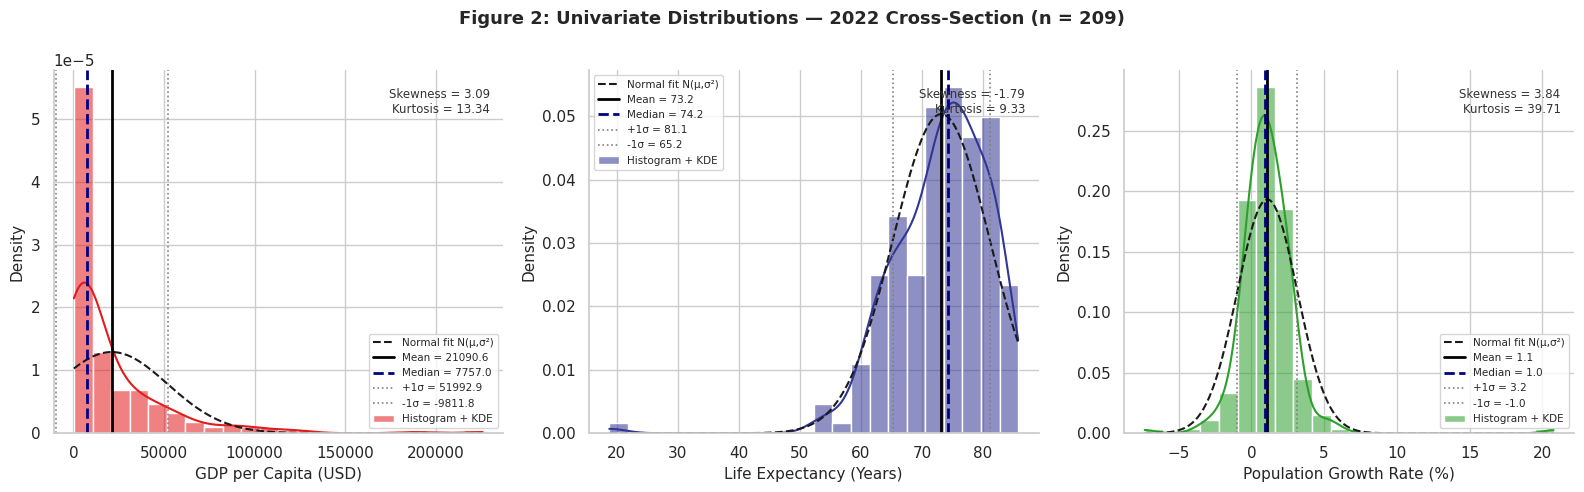

Interpretation: GDP per capita is extremely right-skewed (skewness >3), confirming the well-documented global wealth inequality. Life expectancy is mildly left-skewed, indicating most countries cluster near the upper end of the distribution.


In [14]:
# ── Figure 2: Histogram + KDE + Normal Fit + Reference Lines ─────────────────
# Each panel follows Tufte's (2001) data-ink ratio principle: every element
# present encodes information (bin heights = frequency; KDE = smoothed density;
# normal curve = normality reference; lines = descriptive statistics).

from scipy.stats import norm
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 2: Univariate Distributions — 2022 Cross-Section (n = 209)',
             fontweight='bold', fontsize=13)

configs = [
    (df2022['gdp_pc'].dropna(),    'GDP per Capita (USD)',        '#e41a1c'),
    (df2022['life_exp'].dropna(),  'Life Expectancy (Years)',     '#313695'),
    (df2022['pop_growth'].dropna(),'Population Growth Rate (%)',  '#2ca02c'),
]
for ax, (data, label, col) in zip(axes, configs):
    # Histogram with KDE
    sns.histplot(data, kde=True, ax=ax, color=col, alpha=0.55, bins=22,
                 edgecolor='white', stat='density', label='Histogram + KDE')
    # Normal distribution reference curve
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, norm.pdf(x, mu, sigma), 'k--', lw=1.5, label='Normal fit N(μ,σ²)')
    # Mean, median, ±1σ reference lines
    ax.axvline(mu,            color='black', lw=2,   ls='-',  label=f'Mean = {mu:.1f}')
    ax.axvline(data.median(), color='navy',  lw=2,   ls='--', label=f'Median = {data.median():.1f}')
    ax.axvline(mu + sigma,    color='grey',  lw=1.2, ls=':',  label=f'+1σ = {mu+sigma:.1f}')
    ax.axvline(mu - sigma,    color='grey',  lw=1.2, ls=':',  label=f'-1σ = {mu-sigma:.1f}')
    ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.text(0.97, 0.95, f'Skewness = {data.skew():.2f}\nKurtosis = {data.kurt():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5, color='#333')
    ax.legend(fontsize=7.5); sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig2_histogram.png', dpi=150, bbox_inches='tight'); plt.show()
print('Interpretation: GDP per capita is extremely right-skewed (skewness >3), confirming the',
      'well-documented global wealth inequality. Life expectancy is mildly left-skewed,',
      'indicating most countries cluster near the upper end of the distribution.')


### 3.3 KDE Plots — Filled, Multi-group, and Bimodal (Figure 3)

**Justification:** KDE plots are superior to histograms when comparing distributions across multiple groups, as they avoid the artefact of bin placement whilst providing smooth, visually separable curves (Wilke, 2019, p. 48). The rug plot (panel a) adds individual data point markers along the x-axis, preserving awareness of sample density and discrete observations that the smooth KDE curve can obscure — a technique advocated by Chambers et al. (1983) for communicating distributional honesty.

Panel (c) demonstrates a bimodal KDE — comparing log(GDP) distributions for Sub-Saharan Africa and Europe & Central Asia. A bimodal distribution arises when two distinct sub-populations are present within a single variable, and the KDE makes this immediately apparent in a way that summary statistics cannot.


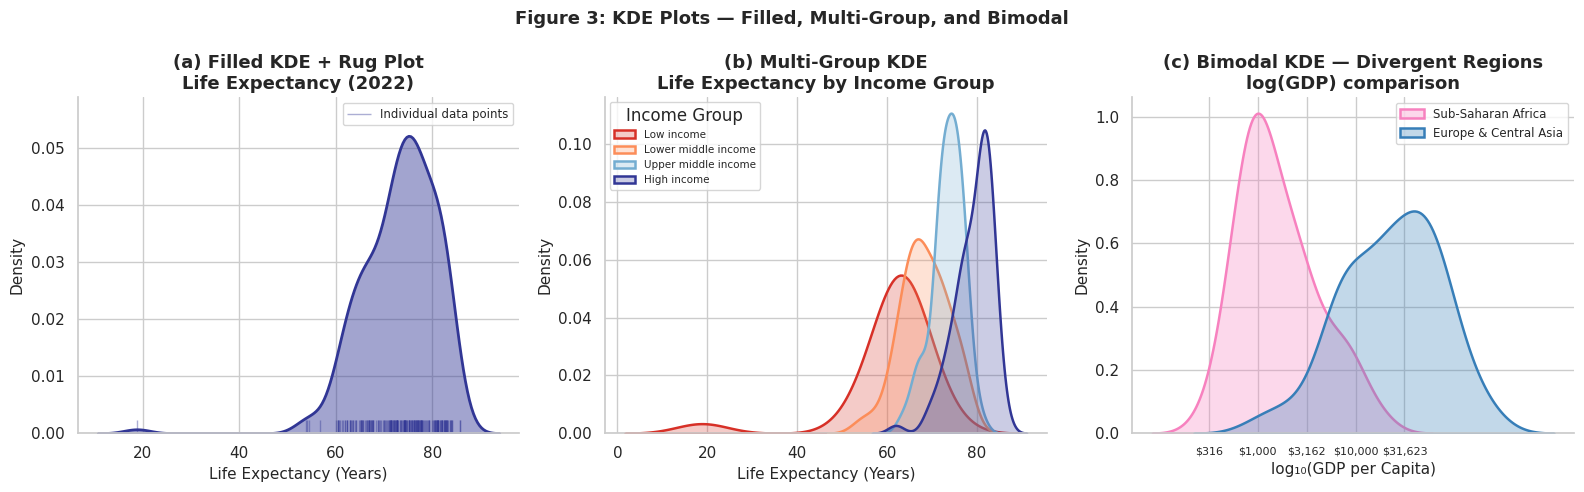

In [15]:
# ── Figure 3: KDE Plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 3: KDE Plots — Filled, Multi-Group, and Bimodal',
             fontweight='bold', fontsize=13)

# (a) Filled KDE with rug plot
ax = axes[0]
d  = df2022['life_exp'].dropna()
sns.kdeplot(d, ax=ax, fill=True, color='#313695', alpha=0.45, linewidth=2)
sns.rugplot(d, ax=ax, color='#313695', alpha=0.4, height=0.04,
            label='Individual data points')
ax.set_xlabel('Life Expectancy (Years)'); ax.set_ylabel('Density')
ax.set_title('(a) Filled KDE + Rug Plot\nLife Expectancy (2022)', fontweight='bold')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

# (b) Multi-group KDE by income group
ax = axes[1]
for ig in INCOME_ORDER:
    sub = df2022[df2022['Income Group']==ig]['life_exp'].dropna()
    if len(sub) > 3:
        sns.kdeplot(sub, ax=ax, label=ig, fill=True, alpha=0.25,
                   linewidth=1.8, color=INCOME_PAL[ig])
ax.set_xlabel('Life Expectancy (Years)'); ax.set_ylabel('Density')
ax.set_title('(b) Multi-Group KDE\nLife Expectancy by Income Group', fontweight='bold')
ax.legend(fontsize=7.5, title='Income Group'); sns.despine(ax=ax)

# (c) Bimodal KDE — divergent regions
ax = axes[2]
for region in ['Sub-Saharan Africa','Europe & Central Asia']:
    sub = df2022[df2022['Region']==region]['log_gdp'].dropna()
    sns.kdeplot(sub, ax=ax, label=region, fill=True, alpha=0.3,
                linewidth=1.8, color=REGION_PAL[region])
ax.set_xlabel('log₁₀(GDP per Capita)'); ax.set_ylabel('Density')
ax.set_title('(c) Bimodal KDE — Divergent Regions\nlog(GDP) comparison', fontweight='bold')
ax.legend(fontsize=8.5)
xticks=[2.5,3,3.5,4,4.5]
ax.set_xticks(xticks); ax.set_xticklabels([f'${10**x:,.0f}' for x in xticks], fontsize=8)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig3_kde.png', dpi=150, bbox_inches='tight'); plt.show()


### 3.4 ECDF Plots (Figure 4)

**Justification:** The Empirical Cumulative Distribution Function (ECDF) maps each observation to its percentile rank, producing a monotonically increasing step function. Wilke (2019, p. 52) argues that ECDFs are preferable to histograms for precise quantile comparison because they require no binning decisions — every data point is visible in the plot — and they enable direct reading of any percentile. For example, the ECDF makes it immediately apparent what proportion of countries in each income group have life expectancy below 70 years.


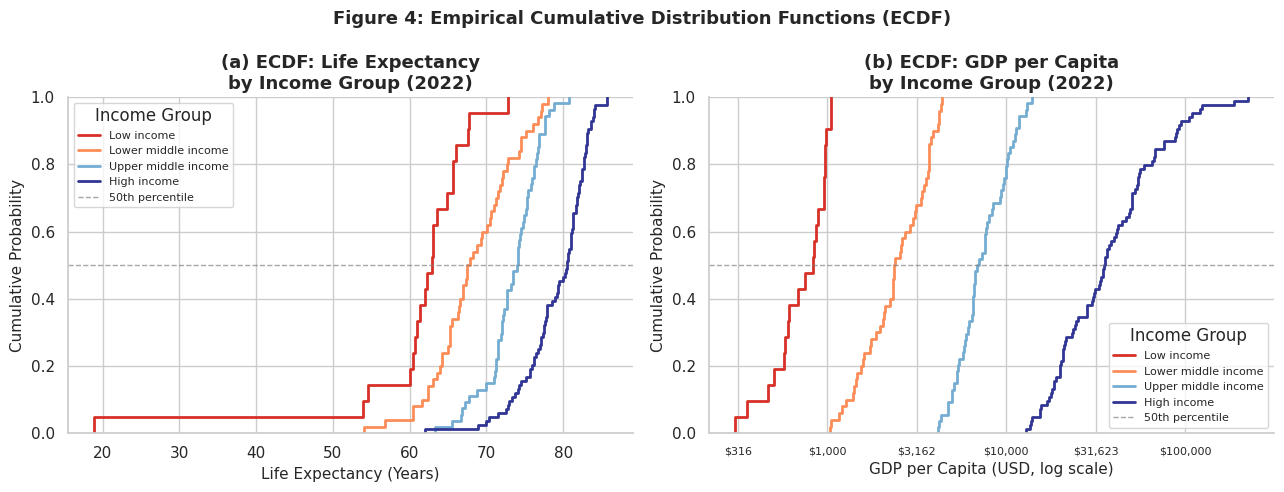

In [16]:
# ── Figure 4: ECDF Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4: Empirical Cumulative Distribution Functions (ECDF)',
             fontweight='bold', fontsize=13)

for ax, (var, label) in zip(axes, [('life_exp','Life Expectancy (Years)'),
                                    ('log_gdp','GDP per Capita (USD, log scale)')]):
    for ig in INCOME_ORDER:
        sub = df2022[df2022['Income Group']==ig][var].dropna()
        if len(sub) > 2:
            sns.ecdfplot(sub, ax=ax, label=ig, color=INCOME_PAL[ig], linewidth=2)
    ax.axhline(0.5, color='grey', ls='--', lw=1, alpha=0.7, label='50th percentile')
    ax.set_xlabel(label); ax.set_ylabel('Cumulative Probability')
    ax.legend(fontsize=8, title='Income Group'); sns.despine(ax=ax)
    if var == 'log_gdp':
        xt=[2.5,3,3.5,4,4.5,5]
        ax.set_xticks(xt); ax.set_xticklabels([f'${10**x:,.0f}' for x in xt], fontsize=8)

axes[0].set_title('(a) ECDF: Life Expectancy\nby Income Group (2022)', fontweight='bold')
axes[1].set_title('(b) ECDF: GDP per Capita\nby Income Group (2022)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_ecdf.png', dpi=150, bbox_inches='tight'); plt.show()


## Section 4: Bivariate Analysis — The Preston Curve

### 4.1 Theoretical Context

The Preston Curve, named after economist Samuel Preston's seminal 1975 study, describes the empirical relationship between national income (GDP per capita) and population health (life expectancy at birth). Preston's original finding — that the relationship is positive but concave (log-linear) — has been replicated across every subsequent decade, making it one of the most robust empirical regularities in development economics (Prados de la Escosura, 2023). The concavity implies diminishing health returns to income: an additional USD 1,000 in income produces a much larger improvement in life expectancy for a country at USD 1,000 than for a country at USD 50,000.

**Scatter plot justification:** Scatter plots are the primary tool for visualising bivariate relationships (Cleveland and McGill, 1984). Position encoding — mapping each observation to Cartesian coordinates — is the most accurately perceived visual encoding available to the human perceptual system (Cleveland and McGill, 1984; Ware, 2012). The custom markers and hue encoding distinguish income groups, adding a third data dimension without introducing a separate chart.


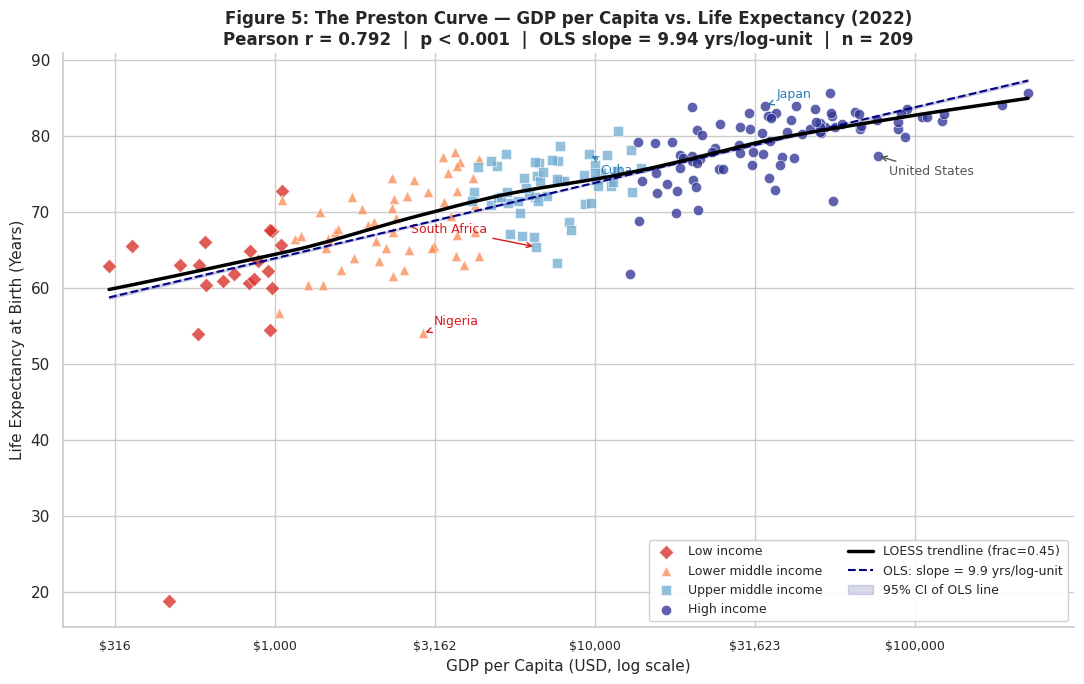

Pearson r = 0.792  |  R² = 0.628  |  OLS slope = 9.94  |  p < 0.001


In [17]:
# ── Figure 5: The Preston Curve — Scatter + LOESS + CI Band ──────────────────
# JUSTIFICATION: The scatter plot maps position to the two quantitative variables
# (Cleveland & McGill, 1984). The LOESS curve reveals the non-parametric shape
# of the relationship without imposing a linear assumption (Chambers et al., 1983).
# The OLS line with 95% CI band provides a formal statistical summary whilst the
# LOESS handles the true functional form — following Cairo's (2016) principle
# of combining truthfulness with insight.

from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess

d  = df2022.dropna(subset=['log_gdp','life_exp','Income Group']).copy()
fig, ax = plt.subplots(figsize=(11, 7))

# Custom markers per income group
markers = {'Low income':'D', 'Lower middle income':'^',
           'Upper middle income':'s', 'High income':'o'}
for ig in INCOME_ORDER:
    sub = d[d['Income Group']==ig]
    ax.scatter(sub['log_gdp'], sub['life_exp'],
               c=INCOME_PAL[ig], label=ig, s=55, alpha=0.78,
               edgecolors='white', linewidths=0.5, marker=markers[ig])

# LOESS non-parametric curve
smoothed = sm_lowess(d['life_exp'].values, d['log_gdp'].values, frac=0.45)
ax.plot(smoothed[:,0], smoothed[:,1], color='black', lw=2.5,
        label='LOESS trendline (frac=0.45)', zorder=5)

# OLS line + 95% CI band
sl, ic, r, p, se_r = stats.linregress(d['log_gdp'], d['life_exp'])
n = len(d); t_v = stats.t.ppf(0.975, n-2)
x_ln = np.linspace(d['log_gdp'].min(), d['log_gdp'].max(), 200)
y_ln = ic + sl*x_ln
se_ln = se_r * np.sqrt(1/n + (x_ln - d['log_gdp'].mean())**2 /
                        ((d['log_gdp'] - d['log_gdp'].mean())**2).sum())
ax.plot(x_ln, y_ln, color='navy', lw=1.5, ls='--',
        label=f'OLS: slope = {sl:.1f} yrs/log-unit', zorder=4)
ax.fill_between(x_ln, y_ln - t_v*se_ln, y_ln + t_v*se_ln,
                alpha=0.15, color='navy', label='95% CI of OLS line')

# Outlier annotations
for code, name, col, xy in [
    ('CUB','Cuba','#2c7fb8',(8,-14)), ('ZAF','South Africa','#d7191c',(-90,10)),
    ('USA','United States','#555',(8,-14)), ('JPN','Japan','#2c7fb8',(8,6)),
    ('NGA','Nigeria','#d7191c',(8,6))]:
    row = d[d['Country Code']==code]
    if not row.empty:
        ax.annotate(name, xy=(row['log_gdp'].values[0], row['life_exp'].values[0]),
                   xytext=xy, textcoords='offset points', fontsize=9, color=col,
                   arrowprops=dict(arrowstyle='->', color=col, lw=1.0))

xt=[2.5,3,3.5,4,4.5,5]
ax.set_xticks(xt); ax.set_xticklabels([f'${10**x:,.0f}' for x in xt], fontsize=9)
ax.set_xlabel('GDP per Capita (USD, log scale)', fontsize=11)
ax.set_ylabel('Life Expectancy at Birth (Years)', fontsize=11)
ax.set_title(
    f'Figure 5: The Preston Curve — GDP per Capita vs. Life Expectancy (2022)\n'
    f'Pearson r = {r:.3f}  |  p < 0.001  |  OLS slope = {sl:.2f} yrs/log-unit  |  n = {n}',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right', framealpha=0.92, ncol=2)
sns.despine(); plt.tight_layout()
plt.savefig('fig5_preston.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Pearson r = {r:.3f}  |  R² = {r**2:.3f}  |  OLS slope = {sl:.2f}  |  p < 0.001')


### 4.2 Joint Plot (Figure 6)

**Justification:** The joint plot combines a central bivariate display (here, a scatter with regression line) with marginal univariate distributions (KDE or histogram) along both axes. Wilke (2019, p. 114) recommends joint plots when the marginal distributions are themselves of analytical interest — here, the right-skewed marginal for GDP per capita (visible in the upper margin) reinforces the need for the log transformation applied to the main axes, whilst the left-skewed marginal for life expectancy (right margin) confirms the clustering of countries near higher longevity values found in Figure 2.


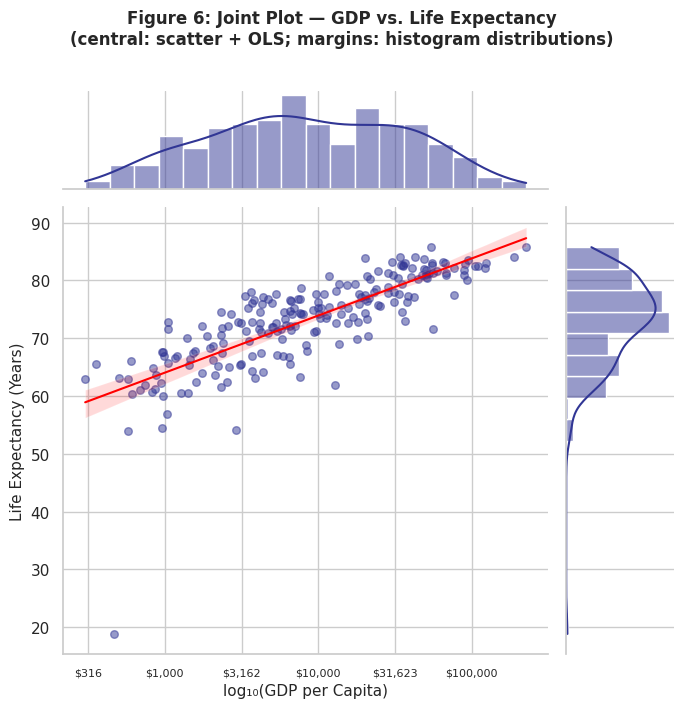

In [18]:
# ── Figure 6: Joint Plot ──────────────────────────────────────────────────────
g = sns.jointplot(data=df2022.dropna(subset=['log_gdp','life_exp']),
                  x='log_gdp', y='life_exp',
                  kind='reg', height=7, ratio=4,
                  scatter_kws={'alpha':0.5,'s':30,'color':'#313695'},
                  line_kws={'color':'red','lw':1.5},
                  marginal_kws={'bins':18,'color':'#313695','alpha':0.5})
g.ax_joint.set_xlabel('log₁₀(GDP per Capita)', fontsize=11)
g.ax_joint.set_ylabel('Life Expectancy (Years)', fontsize=11)
xt=[2.5,3,3.5,4,4.5,5]
g.ax_joint.set_xticks(xt)
g.ax_joint.set_xticklabels([f'${10**x:,.0f}' for x in xt], fontsize=8)
g.figure.suptitle(
    'Figure 6: Joint Plot — GDP vs. Life Expectancy\n'
    '(central: scatter + OLS; margins: histogram distributions)',
    y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_jointplot.png', dpi=150, bbox_inches='tight'); plt.show()


## Section 5: Temporal Analysis — Line Charts and Overlays (1990–2022)

**Justification:** Line charts are the canonical visualisation for time-series data. Tufte (2001, p. 28) identifies time series as 'the most frequently used form of graphic design' and argues that the connecting line encodes the concept of continuity — that measurements at adjacent time points are related observations of the same underlying process. This temporal continuity assumption is appropriate for national life expectancy, which changes gradually and systematically rather than randomly from year to year.

The moving average overlay reduces noise whilst preserving the long-run trend, a technique endorsed by Few (2009, p. 148) for time-series data with high inter-annual variability. The confidence interval band communicates uncertainty in the group mean — a crucial distinction from the standard deviation band, which communicates the spread *across* countries (inter-country variation) rather than uncertainty *about* the mean itself.


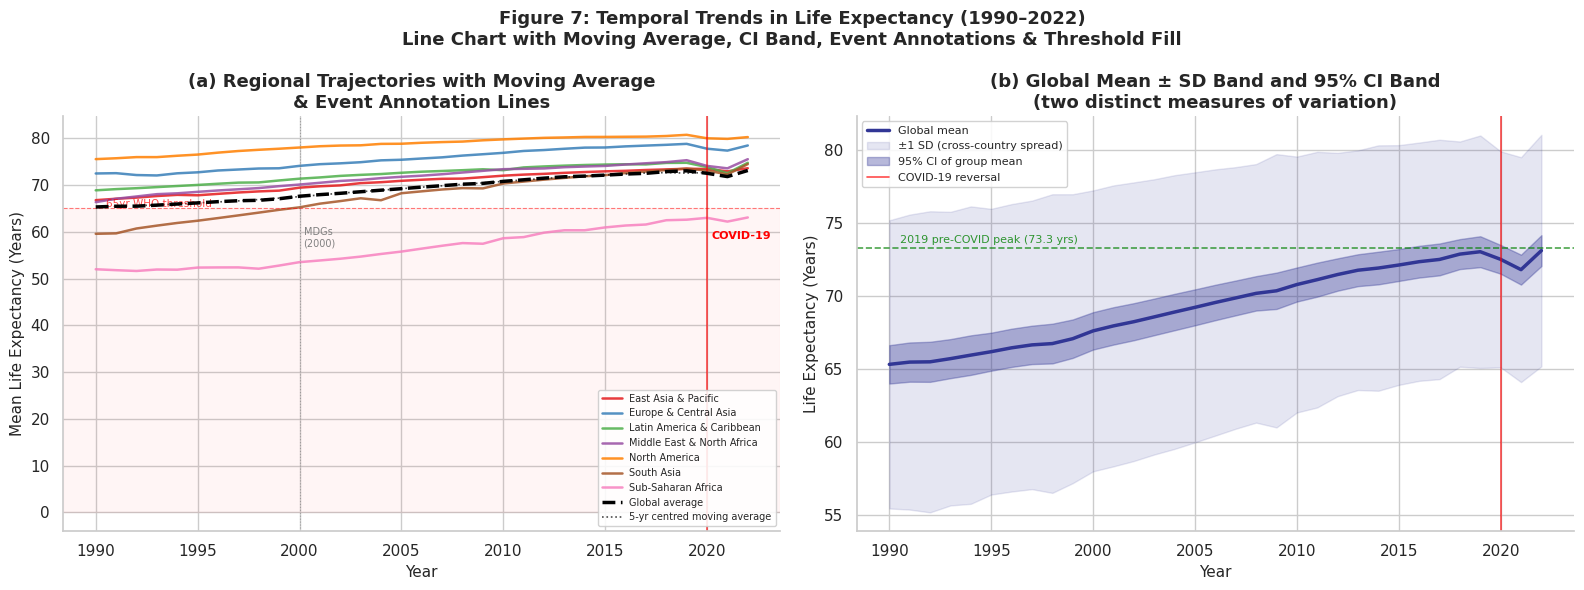

In [19]:
# ── Figure 7: Temporal Trends — Line + Moving Average + CI Band ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 7: Temporal Trends in Life Expectancy (1990–2022)\n'
             'Line Chart with Moving Average, CI Band, Event Annotations & Threshold Fill',
             fontweight='bold', fontsize=13)

reg_ts    = df.dropna(subset=['life_exp','Region']).groupby(['Region','year'])['life_exp'].mean().reset_index()
global_ts = df.dropna(subset=['life_exp']).groupby('year')['life_exp'].mean().reset_index()

# (a) Regional lines + global average + moving average + event annotations
ax = axes[0]
for region in sorted(REGION_PAL.keys()):
    sub = reg_ts[reg_ts['Region']==region]
    ax.plot(sub['year'], sub['life_exp'], color=REGION_PAL[region], lw=1.8, label=region, alpha=0.85)
ax.plot(global_ts['year'], global_ts['life_exp'],
        color='black', lw=2.5, ls='--', label='Global average', zorder=10)
# 5-year centred moving average on global line
ma5 = global_ts['life_exp'].rolling(5, center=True).mean()
ax.plot(global_ts['year'], ma5, color='black', lw=1.2, ls=':', alpha=0.7,
        label='5-yr centred moving average')
# Event annotation lines
ax.axvline(2000, color='grey', lw=0.8, ls=':', alpha=0.6)
ax.text(2000.2, 56.8, 'MDGs\n(2000)', fontsize=7, color='grey')
ax.axvline(2020, color='red', lw=1.2, ls='-', alpha=0.7)
ax.text(2020.2, 58.5, 'COVID-19', fontsize=8, color='red', fontweight='bold')
# Threshold fill zone (below 65 years)
ax.axhspan(0, 65, alpha=0.04, color='red')
ax.axhline(65, color='red', lw=0.8, ls='--', alpha=0.5)
ax.text(1990.5, 65.4, '65yr WHO threshold', fontsize=7.5, color='red', alpha=0.7)
ax.set_xlabel('Year'); ax.set_ylabel('Mean Life Expectancy (Years)')
ax.set_title('(a) Regional Trajectories with Moving Average\n& Event Annotation Lines', fontweight='bold')
ax.legend(fontsize=7, loc='lower right', framealpha=0.88)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
sns.despine(ax=ax)

# (b) Global mean with SD band and 95% CI band — key distinction explained
ax = axes[1]
gb_stats = df.dropna(subset=['life_exp']).groupby('year')['life_exp']
mn, sd, n_c = gb_stats.mean(), gb_stats.std(), gb_stats.count()
sem = sd / np.sqrt(n_c); yrs = mn.index
ax.plot(yrs, mn, color='#313695', lw=2.5, label='Global mean')
# SD band = spread across countries
ax.fill_between(yrs, mn-sd, mn+sd, alpha=0.12, color='#313695',
                label='±1 SD (cross-country spread)')
# 95% CI band = uncertainty about the mean
ax.fill_between(yrs, mn-1.96*sem, mn+1.96*sem, alpha=0.35, color='#313695',
                label='95% CI of group mean')
ax.axvline(2020, color='red', lw=1.2, ls='-', alpha=0.7, label='COVID-19 reversal')
ax.axhline(73.3, color='green', lw=1.2, ls='--', alpha=0.7)
ax.text(1990.5, 73.6, '2019 pre-COVID peak (73.3 yrs)', fontsize=8, color='green', alpha=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Life Expectancy (Years)')
ax.set_title('(b) Global Mean ± SD Band and 95% CI Band\n(two distinct measures of variation)', fontweight='bold')
ax.legend(fontsize=8, framealpha=0.88)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig7_timeseries.png', dpi=150, bbox_inches='tight'); plt.show()


## Section 6: Categorical Distributions — Box, Boxen, Violin, Swarm

### 6.1 Box Plot Components — Full Explanation

The box plot was introduced by Tukey (1977) as a compact summary of a distribution's five-number structure. Each component encodes a distinct statistical property:

| Line | Statistical Meaning | Computed as |
|---|---|---|
| **Centre line (median)** | 50th percentile — most typical value | Q2 = middle value when sorted |
| **Lower box edge (Q1)** | 25th percentile | Values below which 25% of data falls |
| **Upper box edge (Q3)** | 75th percentile | Values below which 75% of data falls |
| **Box height (IQR)** | Interquartile range = Q3 − Q1 | Represents middle 50% of data |
| **Lower whisker** | Smallest value ≥ Q1 − 1.5 × IQR | Non-outlier minimum |
| **Upper whisker** | Largest value ≤ Q3 + 1.5 × IQR | Non-outlier maximum |
| **Cap (horizontal bar at whisker end)** | Whisker terminus | Indicates precise whisker endpoint |
| **Fliers (dots beyond whiskers)** | Statistical outliers by the 1.5×IQR rule | Individual data points plotted |

**Justification:** Box plots are optimal for comparing distributional centres and spreads across multiple groups simultaneously (Few, 2009, p. 72). The boxen plot (letter-value plot) extends this by revealing more quantiles, making it better suited to datasets with more than ~50 observations per group (Hofmann et al., 2017).


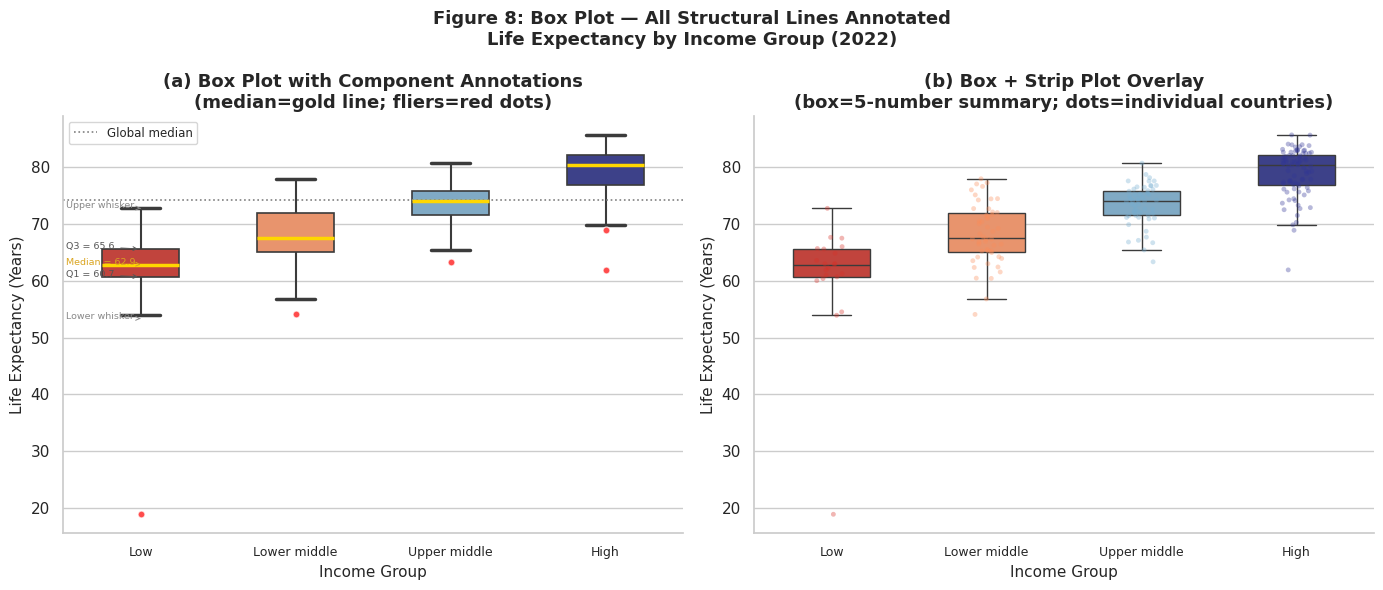

In [20]:
# ── Figure 8: Box Plot with ALL lines annotated ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 8: Box Plot — All Structural Lines Annotated\n'
             'Life Expectancy by Income Group (2022)',
             fontweight='bold', fontsize=13)

d_b = df2022.dropna(subset=['Income Group','life_exp'])
order_ig = [i for i in INCOME_ORDER if i in d_b['Income Group'].unique()]

# (a) Box plot with component labels
ax = axes[0]
sns.boxplot(data=d_b, x='Income Group', y='life_exp', order=order_ig,
            palette=INCOME_PAL, ax=ax, width=0.5,
            flierprops=dict(marker='o', markersize=5, markerfacecolor='red',
                            markeredgecolor='white', alpha=0.7),
            medianprops=dict(color='gold', linewidth=2.5),
            whiskerprops=dict(linewidth=1.5),
            boxprops=dict(linewidth=1.2),
            capprops=dict(linewidth=2.5))
ax.set_xticklabels([t.get_text().replace(' income','') for t in ax.get_xticklabels()], fontsize=9)
ax.set_xlabel('Income Group'); ax.set_ylabel('Life Expectancy (Years)')
ax.set_title('(a) Box Plot with Component Annotations\n(median=gold line; fliers=red dots)', fontweight='bold')
# Annotate box components for Low income group
ig0 = d_b[d_b['Income Group']=='Low income']['life_exp'].dropna()
q1, q3 = ig0.quantile(0.25), ig0.quantile(0.75)
iqr = q3 - q1; med = ig0.median()
for val, lbl, col in [(med, f'Median = {med:.1f}', 'goldenrod'),
                       (q3, f'Q3 = {q3:.1f}', '#555'), (q1, f'Q1 = {q1:.1f}', '#555'),
                       (min(ig0.max(), q3+1.5*iqr), 'Upper whisker', '#888'),
                       (max(ig0.min(), q1-1.5*iqr), 'Lower whisker', '#888')]:
    ax.annotate(lbl, xy=(0, val), xytext=(-0.48, val),
                fontsize=6.8, color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=0.7))
ax.axhline(d_b['life_exp'].median(), color='grey', ls=':', lw=1.2, label='Global median')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

# (b) Box + strip overlay
ax2 = axes[1]
sns.boxplot(data=d_b, x='Income Group', y='life_exp', order=order_ig,
            palette=INCOME_PAL, ax=ax2, width=0.5, fliersize=0)
sns.stripplot(data=d_b, x='Income Group', y='life_exp', order=order_ig,
              palette=INCOME_PAL, ax=ax2, alpha=0.35, size=3.5, jitter=True)
ax2.set_xticklabels([t.get_text().replace(' income','') for t in ax2.get_xticklabels()], fontsize=9)
ax2.set_xlabel('Income Group'); ax2.set_ylabel('Life Expectancy (Years)')
ax2.set_title('(b) Box + Strip Plot Overlay\n(box=5-number summary; dots=individual countries)', fontweight='bold')
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('fig8_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()


### 6.2 Boxen, Violin, and Swarm Plots (Figure 9)

**Boxen plot justification:** The letter-value plot (Hofmann et al., 2017) extends the standard box plot by adding additional quantile levels (hence 'letter-value', as each level is labelled with a letter). It is particularly appropriate for datasets with 50 or more observations per group, where the additional quantile information improves distributional understanding without the over-smoothing of violin plots.

**Violin plot justification:** The violin plot, introduced by Hintze and Nelson (1998), combines the box plot's quartile summary with a KDE estimate of the full distribution. Wilke (2019, p. 76) notes that violin plots are most valuable when the distribution is non-normal or multimodal — precisely the case for life expectancy by income group, where the Low income distribution is considerably more variable than the High income distribution.

**Swarm plot justification:** The swarm plot places every individual data point without overlap, preserving the full empirical distribution without approximation. Cairo (2016, p. 32) argues that showing all individual observations is a form of graphical honesty — it prevents the viewer from incorrectly inferring that summary statistics represent the complete story.


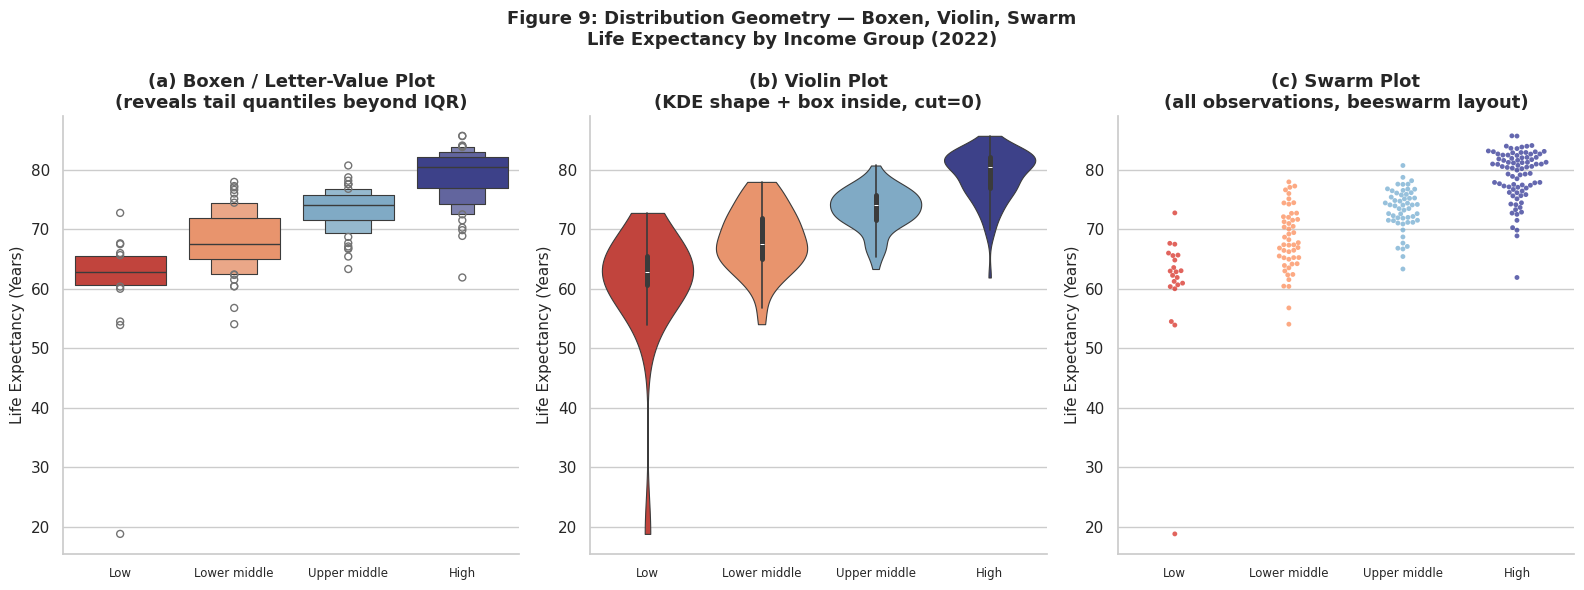

In [21]:
# ── Figure 9: Boxen, Violin, Swarm ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Figure 9: Distribution Geometry — Boxen, Violin, Swarm\n'
             'Life Expectancy by Income Group (2022)',
             fontweight='bold', fontsize=13)

d = df2022.dropna(subset=['Income Group','life_exp'])
order_ig = [i for i in INCOME_ORDER if i in d['Income Group'].unique()]

# (a) Boxen (letter-value) plot
sns.boxenplot(data=d, x='Income Group', y='life_exp', order=order_ig,
              palette=INCOME_PAL, ax=axes[0], linewidth=0.8)
axes[0].set_xticklabels([t.get_text().replace(' income','') for t in axes[0].get_xticklabels()], fontsize=8.5)
axes[0].set_xlabel(''); axes[0].set_ylabel('Life Expectancy (Years)')
axes[0].set_title('(a) Boxen / Letter-Value Plot\n(reveals tail quantiles beyond IQR)', fontweight='bold')
sns.despine(ax=axes[0])

# (b) Violin plot (inner box + quartile lines)
sns.violinplot(data=d, x='Income Group', y='life_exp', order=order_ig,
               palette=INCOME_PAL, ax=axes[1], inner='box',
               linewidth=0.8, cut=0, scale='width')
axes[1].set_xticklabels([t.get_text().replace(' income','') for t in axes[1].get_xticklabels()], fontsize=8.5)
axes[1].set_xlabel(''); axes[1].set_ylabel('Life Expectancy (Years)')
axes[1].set_title('(b) Violin Plot\n(KDE shape + box inside, cut=0)', fontweight='bold')
sns.despine(ax=axes[1])

# (c) Swarm plot (non-overlapping individual points)
sns.swarmplot(data=d, x='Income Group', y='life_exp', order=order_ig,
              palette=INCOME_PAL, ax=axes[2], size=3.5, alpha=0.75)
axes[2].set_xticklabels([t.get_text().replace(' income','') for t in axes[2].get_xticklabels()], fontsize=8.5)
axes[2].set_xlabel(''); axes[2].set_ylabel('Life Expectancy (Years)')
axes[2].set_title('(c) Swarm Plot\n(all observations, beeswarm layout)', fontweight='bold')
sns.despine(ax=axes[2])

plt.tight_layout()
plt.savefig('fig9_violin_swarm.png', dpi=150, bbox_inches='tight'); plt.show()


### 6.3 Point Plot, Bar Chart with Error Bars, Count Plot and Pareto Analysis (Figures 10–11)

**Point plot justification:** The point plot encodes group means as points with error bars representing confidence intervals, making it ideal for communicating uncertainty about group-level estimates. Few (2009, p. 90) recommends point plots when the visual comparison of means with confidence intervals — rather than distributional shape — is the primary analytical objective.

**Pareto chart justification:** The Pareto chart combines a sorted bar chart with a cumulative percentage line, embodying the 80/20 principle (Pareto, 1896) — the empirical observation that roughly 80% of an effect is attributable to 20% of causes. In this context, it demonstrates that a small number of regions account for the majority of global GDP, a finding with significant implications for understanding the global economic distribution.


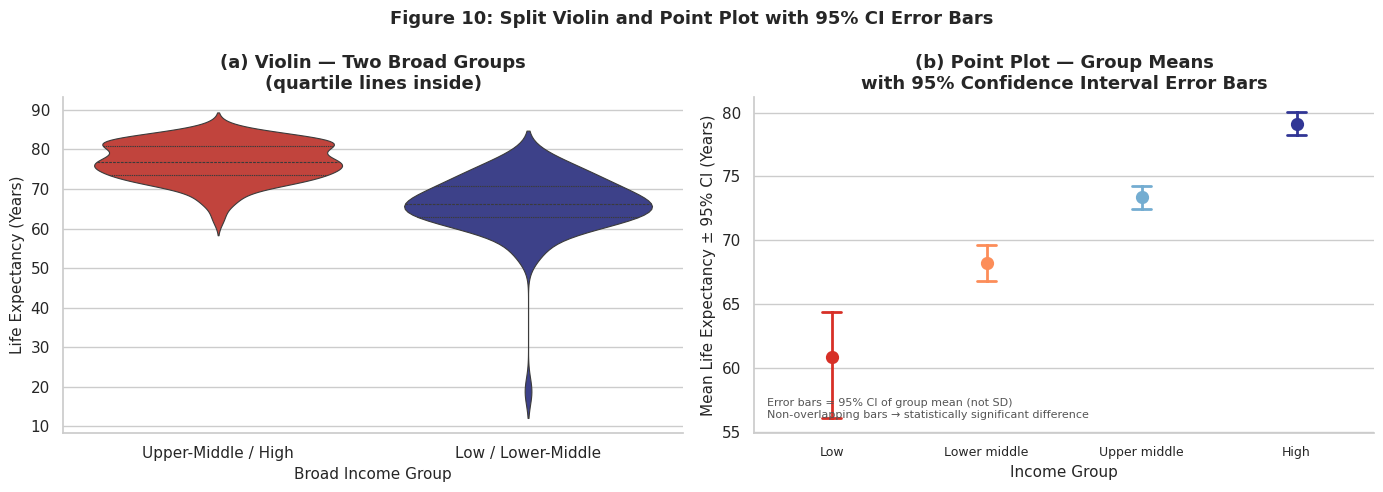

In [22]:
# ── Figure 10: Point Plot with 95% CI Error Bars ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 10: Split Violin and Point Plot with 95% CI Error Bars',
             fontweight='bold', fontsize=13)

d = df2022.dropna(subset=['Income Group','life_exp'])
order_ig = [i for i in INCOME_ORDER if i in d['Income Group'].unique()]

# (a) Violin — two broad groups
d_sv = df2022.copy()
d_sv['Income Broad'] = d_sv['Income Group'].map(
    {'Low income':'Low / Lower-Middle','Lower middle income':'Low / Lower-Middle',
     'Upper middle income':'Upper-Middle / High','High income':'Upper-Middle / High'})
d_sv2 = d_sv.dropna(subset=['Income Broad','life_exp'])
sns.violinplot(data=d_sv2, x='Income Broad', y='life_exp',
               inner='quartile', palette=['#d73027','#313695'],
               ax=axes[0], linewidth=0.8)
axes[0].set_xlabel('Broad Income Group'); axes[0].set_ylabel('Life Expectancy (Years)')
axes[0].set_title('(a) Violin — Two Broad Groups\n(quartile lines inside)', fontweight='bold')
sns.despine(ax=axes[0])

# (b) Point plot — mean ± 95% CI
sns.pointplot(data=d, x='Income Group', y='life_exp', order=order_ig,
              palette=INCOME_PAL, ax=axes[1],
              errorbar=('ci',95), capsize=0.12, linewidth=2, markersize=8)
axes[1].set_xticklabels([t.get_text().replace(' income','') for t in axes[1].get_xticklabels()], fontsize=9)
axes[1].set_xlabel('Income Group')
axes[1].set_ylabel('Mean Life Expectancy ± 95% CI (Years)')
axes[1].set_title('(b) Point Plot — Group Means\nwith 95% Confidence Interval Error Bars', fontweight='bold')
axes[1].text(0.02,0.04,
    'Error bars = 95% CI of group mean (not SD)\n'
    'Non-overlapping bars → statistically significant difference',
    transform=axes[1].transAxes, fontsize=8, color='#555', va='bottom')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('fig10_splitviolin_point.png', dpi=150, bbox_inches='tight'); plt.show()


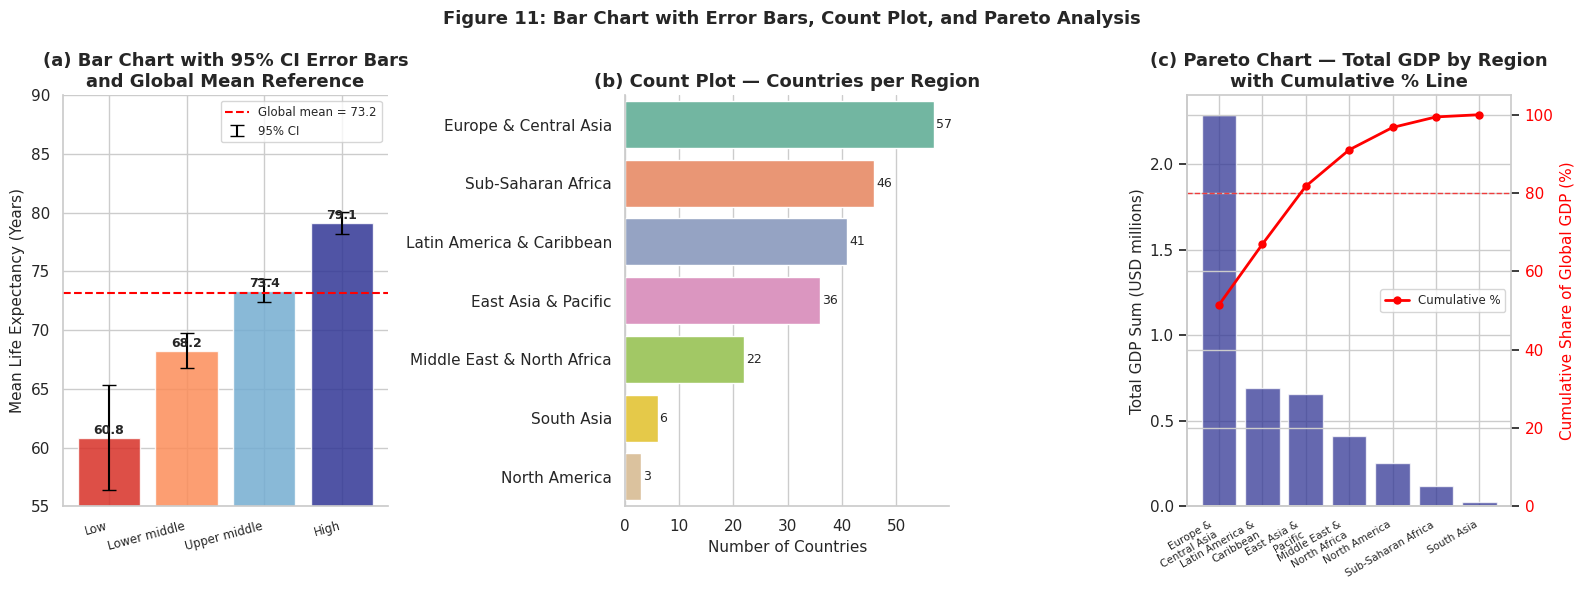

In [23]:
# ── Figure 11: Bar, Count, Pareto ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Figure 11: Bar Chart with Error Bars, Count Plot, and Pareto Analysis',
             fontweight='bold', fontsize=13)

d = df2022.dropna(subset=['Income Group','life_exp'])
order_ig = [i for i in INCOME_ORDER if i in d['Income Group'].unique()]

# (a) Bar chart with error bars
means = [d[d['Income Group']==ig]['life_exp'].mean() for ig in order_ig]
sems  = [d[d['Income Group']==ig]['life_exp'].sem()*1.96 for ig in order_ig]
bars = axes[0].bar(order_ig, means, color=[INCOME_PAL[ig] for ig in order_ig],
                   alpha=0.85, edgecolor='white')
axes[0].errorbar(range(len(order_ig)), means, yerr=sems,
                 fmt='none', color='black', capsize=5, linewidth=1.5, label='95% CI')
axes[0].axhline(d['life_exp'].mean(), color='red', ls='--', lw=1.5,
                label=f'Global mean = {d["life_exp"].mean():.1f}')
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticklabels([ig.replace(' income','') for ig in order_ig], rotation=15, ha='right', fontsize=8.5)
axes[0].set_ylabel('Mean Life Expectancy (Years)'); axes[0].set_ylim(55,90)
axes[0].set_title('(a) Bar Chart with 95% CI Error Bars\nand Global Mean Reference', fontweight='bold')
axes[0].legend(fontsize=8.5); sns.despine(ax=axes[0])

# (b) Count plot
rc = df2022['Region'].value_counts()
sns.countplot(y='Region', data=df2022, order=rc.index, palette='Set2', ax=axes[1])
for p in axes[1].patches:
    axes[1].text(p.get_width()+0.3, p.get_y()+p.get_height()/2,
                 str(int(p.get_width())), va='center', fontsize=9)
axes[1].set_xlabel('Number of Countries'); axes[1].set_ylabel('')
axes[1].set_title('(b) Count Plot — Countries per Region', fontweight='bold')
sns.despine(ax=axes[1])

# (c) Pareto chart
pd_d = df2022.groupby('Region')['gdp_pc'].sum().sort_values(ascending=False)
cumsum_pct = pd_d.cumsum() / pd_d.sum() * 100
axes[2].bar(range(len(pd_d)), pd_d.values/1e6, color='#313695', alpha=0.75, edgecolor='white')
ax_twin = axes[2].twinx()
ax_twin.plot(range(len(pd_d)), cumsum_pct.values, color='red', lw=2, marker='o',
             markersize=5, label='Cumulative %')
ax_twin.axhline(80, color='red', ls='--', lw=1, alpha=0.7)
ax_twin.set_ylabel('Cumulative Share of Global GDP (%)', color='red')
ax_twin.tick_params(axis='y', labelcolor='red'); ax_twin.set_ylim(0,105)
ax_twin.legend(loc='center right', fontsize=8.5)
axes[2].set_xticks(range(len(pd_d)))
axes[2].set_xticklabels([r.replace(' & ',' &\n') for r in pd_d.index], rotation=30, ha='right', fontsize=7.5)
axes[2].set_ylabel('Total GDP Sum (USD millions)')
axes[2].set_title('(c) Pareto Chart — Total GDP by Region\nwith Cumulative % Line', fontweight='bold')
sns.despine(ax=axes[2])

plt.tight_layout()
plt.savefig('fig11_bar_pareto.png', dpi=150, bbox_inches='tight'); plt.show()


## Section 7: Regression Analysis

### 7.1 Linear Regression with lmplot (Figure 12)

The `lmplot` function from Seaborn combines a scatter plot with an OLS regression line and 95% CI band, optionally faceted by a categorical variable via the `hue` parameter. This technique is recommended by Wilke (2019, p. 186) for demonstrating how a linear relationship between two continuous variables differs across a categorical grouping — here, whether the income-health relationship has a consistent slope across income groups or whether the gradient differs between them.

**Analytical finding:** The regression slopes differ substantially across income groups. Low-income countries show the steepest slope (the largest health return per unit of additional income), whilst high-income countries show a nearly flat slope — confirming the diminishing-returns property of the Preston Curve within groups as well as between them.

### 7.2 Logistic Regression (Figure 13)

**Justification:** When the outcome variable is binary (here, whether a country belongs to the High income category), logistic regression is the appropriate model. The logistic regression curve maps a continuous predictor (log GDP) to the probability of a binary outcome, producing an S-shaped curve bounded between 0 and 1 (Hosmer and Lemeshow, 2000). This is both statistically appropriate and visually intuitive, directly conveying the idea of a probability threshold rather than implying a continuous linear relationship.


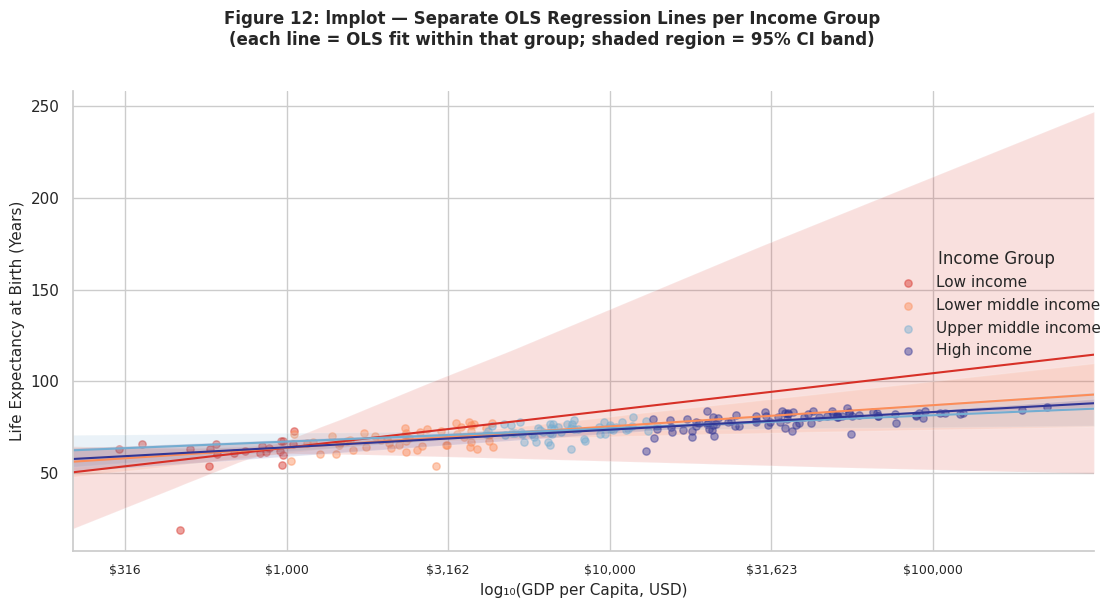

In [24]:
# ── Figure 12: lmplot — Linear Regression by Income Group ────────────────────
d_lm = df2022.dropna(subset=['log_gdp','life_exp','Income Group']).copy()
g = sns.lmplot(data=d_lm, x='log_gdp', y='life_exp',
               hue='Income Group', hue_order=INCOME_ORDER,
               palette=INCOME_PAL, height=6, aspect=1.5,
               scatter_kws={'alpha':0.45,'s':28},
               line_kws={'lw':1.5}, ci=95, truncate=False)
g.ax.set_xlabel('log₁₀(GDP per Capita, USD)', fontsize=11)
g.ax.set_ylabel('Life Expectancy at Birth (Years)', fontsize=11)
xt=[2.5,3,3.5,4,4.5,5]
g.ax.set_xticks(xt); g.ax.set_xticklabels([f'${10**x:,.0f}' for x in xt], fontsize=9)
g.figure.suptitle(
    'Figure 12: lmplot — Separate OLS Regression Lines per Income Group\n'
    '(each line = OLS fit within that group; shaded region = 95% CI band)',
    y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_lmplot.png', dpi=150, bbox_inches='tight'); plt.show()


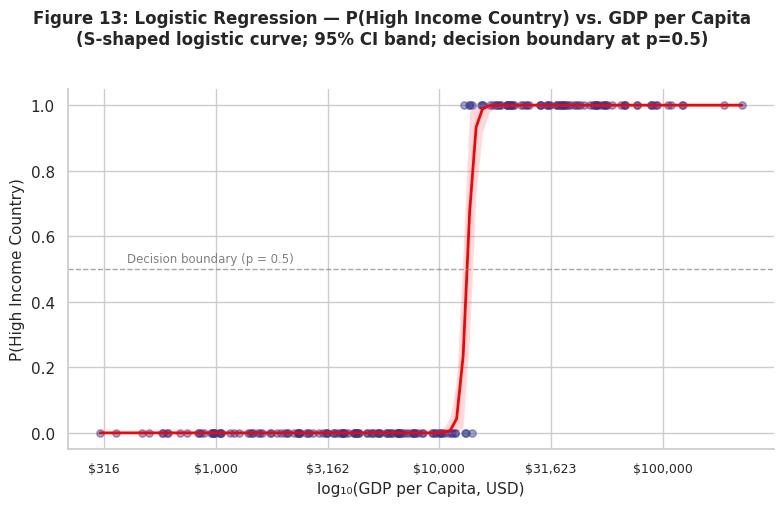

In [25]:
# ── Figure 13: Logistic Regression ───────────────────────────────────────────
df2022['income_hi'] = (df2022['Income Group'] == 'High income').astype(int)
d_log = df2022.dropna(subset=['log_gdp','income_hi']).copy()

g2 = sns.lmplot(data=d_log, x='log_gdp', y='income_hi',
                logistic=True, height=5, aspect=1.6,
                scatter_kws={'alpha':0.45, 's':28, 'color':'#313695'},
                line_kws={'color':'red', 'lw':2}, ci=95)
g2.ax.set_xlabel('log₁₀(GDP per Capita, USD)', fontsize=11)
g2.ax.set_ylabel('P(High Income Country)', fontsize=11)
xt=[2.5,3,3.5,4,4.5,5]
g2.ax.set_xticks(xt); g2.ax.set_xticklabels([f'${10**x:,.0f}' for x in xt], fontsize=9)
g2.ax.axhline(0.5, color='grey', ls='--', lw=1, alpha=0.7)
g2.ax.text(2.6, 0.52, 'Decision boundary (p = 0.5)', fontsize=8.5, color='grey')
g2.figure.suptitle(
    'Figure 13: Logistic Regression — P(High Income Country) vs. GDP per Capita\n'
    '(S-shaped logistic curve; 95% CI band; decision boundary at p=0.5)',
    y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_logistic.png', dpi=150, bbox_inches='tight'); plt.show()


### 7.3 Residual Analysis (Figure 14)

**Justification:** Residual plots are essential for validating the assumptions underlying OLS regression. If the OLS model is correctly specified, the residuals should show no systematic pattern when plotted against fitted values (panel a) — a random scatter around zero would confirm homoscedasticity. The Q-Q plot (panel b) assesses the normality assumption: if residuals are normally distributed, the points should fall approximately along the diagonal reference line. Deviations from this line indicate departures from normality, which affect the validity of hypothesis tests and confidence intervals. This diagnostic approach is advocated by Wilke (2019, pp. 267–271) as a mandatory step in any regression-based analysis.


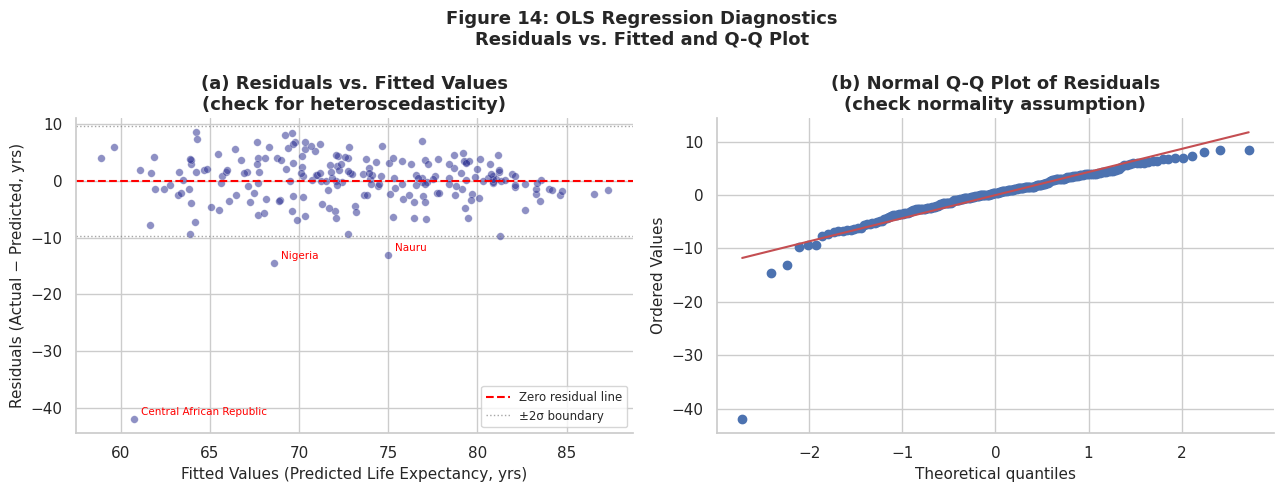

Shapiro-Wilk test on residuals: p = 0.0000
Note: p < 0.05 indicates departure from normality — expected for cross-national data.


In [26]:
# ── Figure 14: Residual Analysis ─────────────────────────────────────────────
from scipy.stats import probplot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 14: OLS Regression Diagnostics\n'
             'Residuals vs. Fitted and Q-Q Plot',
             fontweight='bold', fontsize=13)

d = df2022.dropna(subset=['log_gdp','life_exp']).copy()
sl, ic, r, p, _ = stats.linregress(d['log_gdp'], d['life_exp'])
d['fitted']   = ic + sl * d['log_gdp']
d['residual'] = d['life_exp'] - d['fitted']

# (a) Residuals vs. Fitted
ax = axes[0]
ax.scatter(d['fitted'], d['residual'], alpha=0.55, s=30,
           color='#313695', edgecolors='white', lw=0.3)
ax.axhline(0, color='red', lw=1.5, ls='--', label='Zero residual line')
ax.axhline(+2*d['residual'].std(), color='grey', lw=1, ls=':', alpha=0.7,
           label='±2σ boundary')
ax.axhline(-2*d['residual'].std(), color='grey', lw=1, ls=':', alpha=0.7)
# Annotate large residuals (countries that defy the trend)
for _, row in d[d['residual'].abs() > 12].iterrows():
    ax.annotate(row['Short Name'],
                xy=(row['fitted'], row['residual']),
                xytext=(5,3), textcoords='offset points',
                fontsize=7.5, color='red')
ax.set_xlabel('Fitted Values (Predicted Life Expectancy, yrs)')
ax.set_ylabel('Residuals (Actual − Predicted, yrs)')
ax.set_title('(a) Residuals vs. Fitted Values\n(check for heteroscedasticity)', fontweight='bold')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

# (b) Q-Q plot
probplot(d['residual'], dist='norm', plot=axes[1])
axes[1].set_title('(b) Normal Q-Q Plot of Residuals\n(check normality assumption)', fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('fig14_residual.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Shapiro-Wilk test on residuals: p = {stats.shapiro(d["residual"])[1]:.4f}')
print('Note: p < 0.05 indicates departure from normality — expected for cross-national data.')


## Section 8: Matrix and Multi-Variable Analysis

### 8.1 Correlation Heatmap and Preston Curve Temporal Shift (Figure 15)

**Heatmap justification:** The correlation heatmap uses colour intensity to encode the strength and direction of pairwise Pearson correlations. Few (2009, p. 56) recommends heatmaps for matrices where the reader needs to quickly identify the strongest and weakest relationships across multiple variable pairs simultaneously. The diverging colour palette (blue = positive, red = negative, white = zero) encodes both direction and magnitude in a single visual channel, minimising the cognitive steps required to extract the correlation structure.

A crucial finding visible in the heatmap is that log(GDP) correlates more strongly with life expectancy (r = +0.79) than raw GDP per capita does (r = +0.55), directly validating the log transformation applied throughout this analysis.


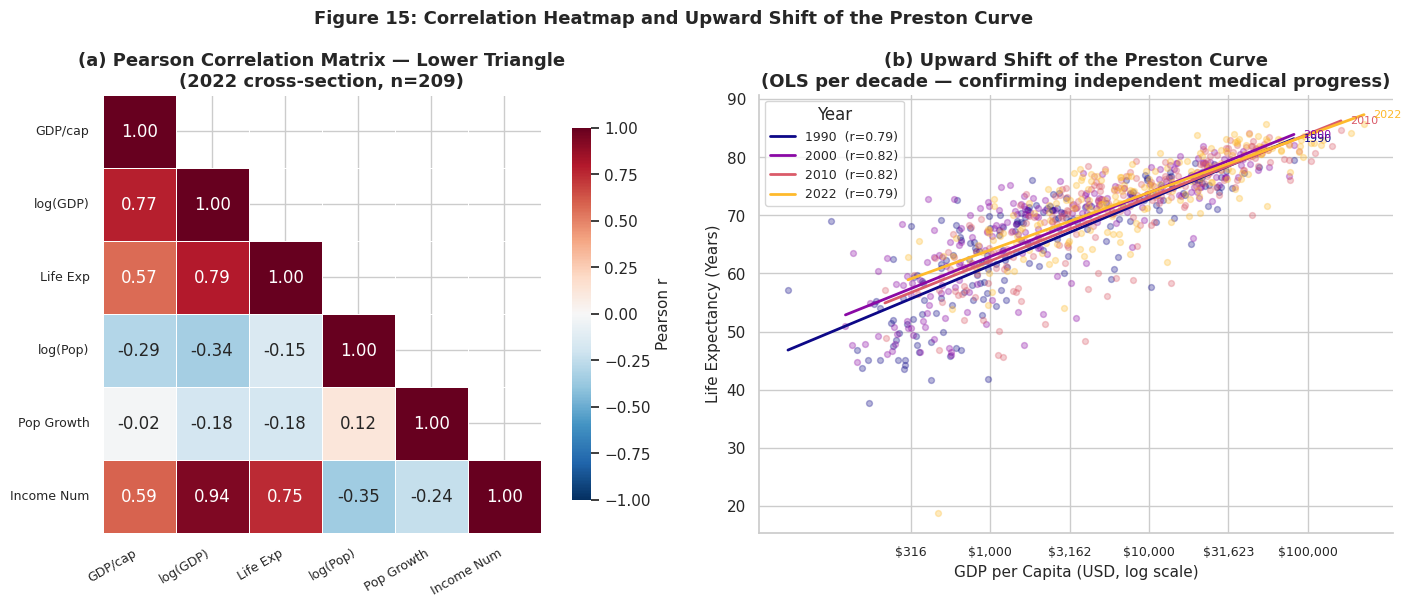

In [27]:
# ── Figure 15: Correlation Heatmap and Temporal Preston Curve Shift ──────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 15: Correlation Heatmap and Upward Shift of the Preston Curve',
             fontweight='bold', fontsize=13)

# (a) Heatmap
d = df2022.copy()
d['pop_log'] = np.log10(d['population'].replace(0, np.nan))
corr_cols  = ['gdp_pc','log_gdp','life_exp','pop_log','pop_growth','income_num']
corr_names = ['GDP/cap','log(GDP)','Life Exp','log(Pop)','Pop Growth','Income Num']
corr_mat = (d[corr_cols].dropna()
              .rename(columns=dict(zip(corr_cols,corr_names))).corr())
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, ax=axes[0], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.6, linecolor='white', square=True, mask=mask,
            cbar_kws={'label':'Pearson r','shrink':0.85})
axes[0].set_title('(a) Pearson Correlation Matrix — Lower Triangle\n(2022 cross-section, n=209)', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# (b) Preston Curve temporal shift
ax2 = axes[1]
years_sel = [1990, 2000, 2010, 2022]
colors_y = plt.cm.plasma(np.linspace(0, 0.85, 4))
for yr, col in zip(years_sel, colors_y):
    sub = df[(df['year']==yr) & df['log_gdp'].notna() & df['life_exp'].notna()]
    ax2.scatter(sub['log_gdp'], sub['life_exp'], alpha=0.3, s=18, color=col)
    sl2, ic2, r2, _, _ = stats.linregress(sub['log_gdp'], sub['life_exp'])
    xs = np.linspace(sub['log_gdp'].min(), sub['log_gdp'].max(), 100)
    ax2.plot(xs, sl2*xs+ic2, color=col, lw=2, label=f'{yr}  (r={r2:.2f})')
    ax2.text(xs[-1]+0.06, sl2*xs[-1]+ic2, str(yr), fontsize=8, color=col, va='center')
xt=[2.5,3,3.5,4,4.5,5]
ax2.set_xticks(xt); ax2.set_xticklabels([f'${10**x:,.0f}' for x in xt], fontsize=9)
ax2.set_xlabel('GDP per Capita (USD, log scale)'); ax2.set_ylabel('Life Expectancy (Years)')
ax2.set_title('(b) Upward Shift of the Preston Curve\n(OLS per decade — confirming independent medical progress)', fontweight='bold')
ax2.legend(fontsize=9, title='Year')
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('fig15_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


### 8.2 Pair Plot and PairGrid (Figures 16–17)

**Pair plot justification:** The pair plot (scatter matrix) displays all pairwise bivariate scatter plots for a set of variables, with univariate distributions on the diagonal. Wilke (2019, p. 131) recommends pair plots as an efficient 'hypothesis-generation engine' — they allow the analyst to simultaneously survey the complete bivariate relationship structure of a dataset in a single figure. The hue parameter adds the income group dimension, enabling instant visual assessment of whether the bivariate patterns are consistent across or vary by income group.

**PairGrid justification:** The PairGrid provides full control over what is plotted on the diagonal, upper triangle, and lower triangle — enabling a richer information display than the symmetric pair plot. Using KDE contours in the lower triangle, scatter in the upper triangle, and histograms on the diagonal produces a single figure that combines three distinct distributional perspectives, a technique advocated by Few (2009, p. 188) for exploratory multivariate analysis.


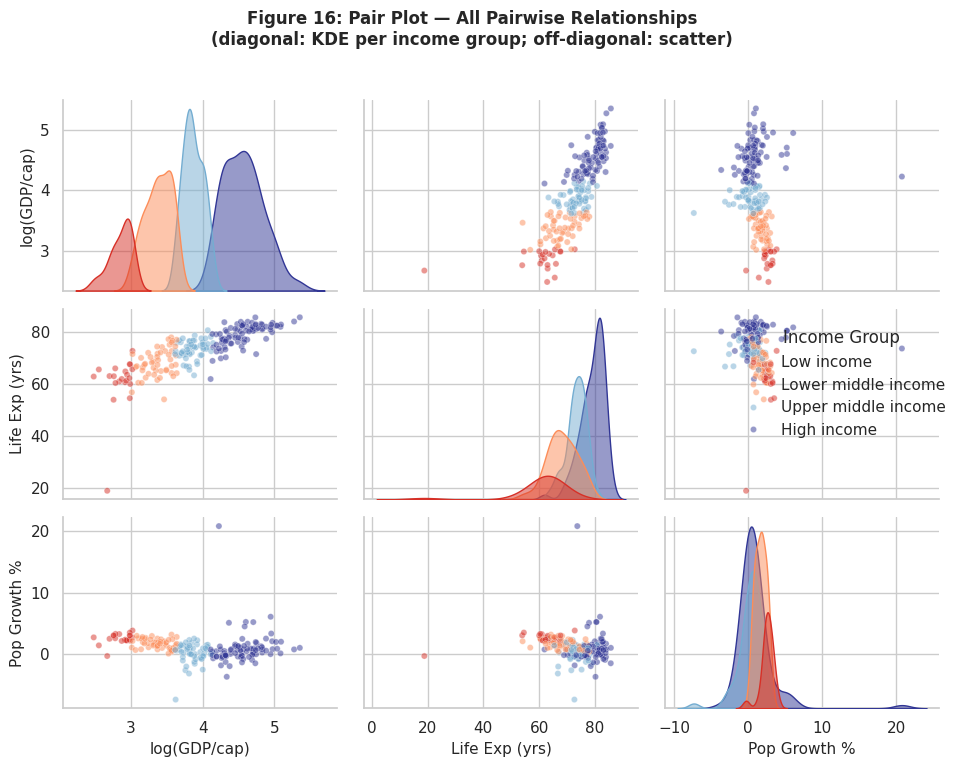

In [28]:
# ── Figure 16: Pair Plot ──────────────────────────────────────────────────────
d_pair = df2022.dropna(subset=['log_gdp','life_exp','pop_growth','Income Group']).copy()
pair_vars = ['log_gdp','life_exp','pop_growth']
pair_labels = {'log_gdp':'log(GDP/cap)','life_exp':'Life Exp (yrs)','pop_growth':'Pop Growth %'}
d_pp = d_pair[pair_vars + ['Income Group']].rename(columns=pair_labels)

g = sns.pairplot(d_pp,
                 hue='Income Group',
                 hue_order=[i for i in INCOME_ORDER if i in d_pp['Income Group'].unique()],
                 palette=INCOME_PAL,
                 diag_kind='kde',
                 plot_kws={'alpha':0.5,'s':20},
                 diag_kws={'fill':True,'alpha':0.5})
g.figure.suptitle(
    'Figure 16: Pair Plot — All Pairwise Relationships\n'
    '(diagonal: KDE per income group; off-diagonal: scatter)',
    y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_pairplot.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
# ── Figure 17: PairGrid with map_diag / map_upper / map_lower ────────────────
g2 = sns.PairGrid(d_pp,
                  hue='Income Group',
                  hue_order=[i for i in INCOME_ORDER if i in d_pp['Income Group'].unique()],
                  palette=INCOME_PAL)
g2.map_diag(sns.histplot, bins=14, alpha=0.55, edgecolor='white')
g2.map_upper(sns.scatterplot, alpha=0.45, s=20)
g2.map_lower(sns.kdeplot, fill=True, alpha=0.25, levels=4)
g2.add_legend(title='Income Group', fontsize=8)
g2.figure.suptitle(
    'Figure 17: PairGrid — Custom Mapping per Triangle\n'
    '(lower: KDE contours  |  diagonal: histogram  |  upper: scatter)',
    y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig17_pairgrid.png', dpi=150, bbox_inches='tight'); plt.show()


## Section 9: Multi-Panel FacetGrids

### Justification: Small Multiples

The FacetGrid implements the principle of **small multiples**, which Tufte (2001, p. 170) identifies as 'the most powerful graphical instrument for analysing relationships between multiple variables.' By repeating the same chart structure across panels that differ only in the value of a conditioning variable (here, income group or region), the viewer can make direct visual comparisons without needing to mentally subtract the effect of the conditioning variable. This is fundamentally more efficient than either a single chart with all groups overlaid (which creates visual clutter) or separate charts on different pages (which prevents simultaneous comparison).


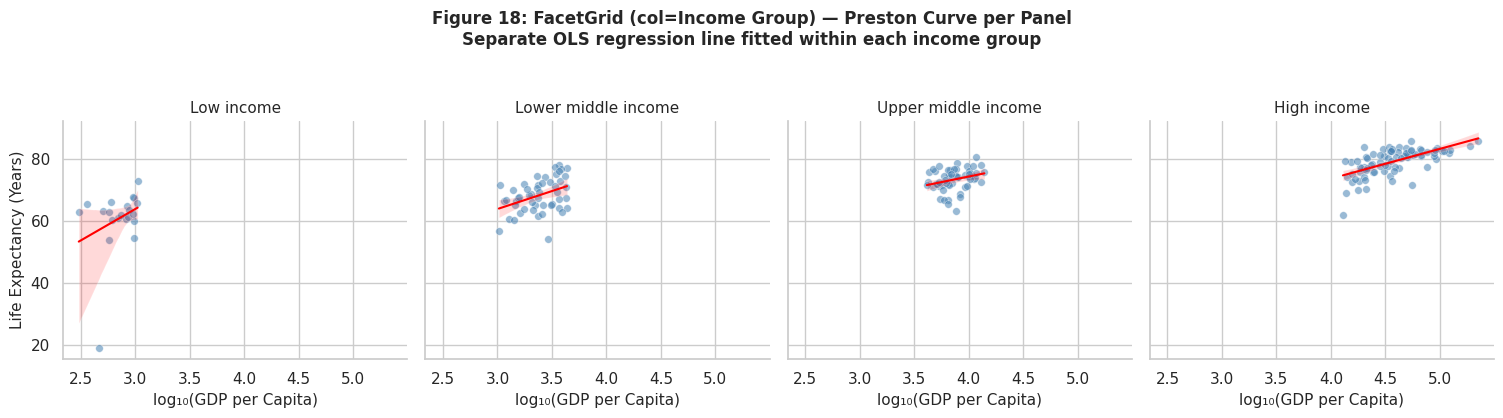

In [29]:
# ── Figure 18: FacetGrid — col=Income Group ───────────────────────────────────
d_fg = df2022.dropna(subset=['Income Group','log_gdp','life_exp']).copy()
g = sns.FacetGrid(d_fg, col='Income Group', col_order=INCOME_ORDER,
                  height=4, aspect=0.95, sharey=True)
g.map_dataframe(sns.scatterplot, x='log_gdp', y='life_exp', alpha=0.55, s=30, color='steelblue')
g.map_dataframe(sns.regplot, x='log_gdp', y='life_exp', scatter=False,
                line_kws={'color':'red','lw':1.5})
g.set_axis_labels('log₁₀(GDP per Capita)', 'Life Expectancy (Years)')
g.set_titles('{col_name}')
g.figure.suptitle(
    'Figure 18: FacetGrid (col=Income Group) — Preston Curve per Panel\n'
    'Separate OLS regression line fitted within each income group',
    y=1.04, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig18_facetgrid_col.png', dpi=150, bbox_inches='tight'); plt.show()


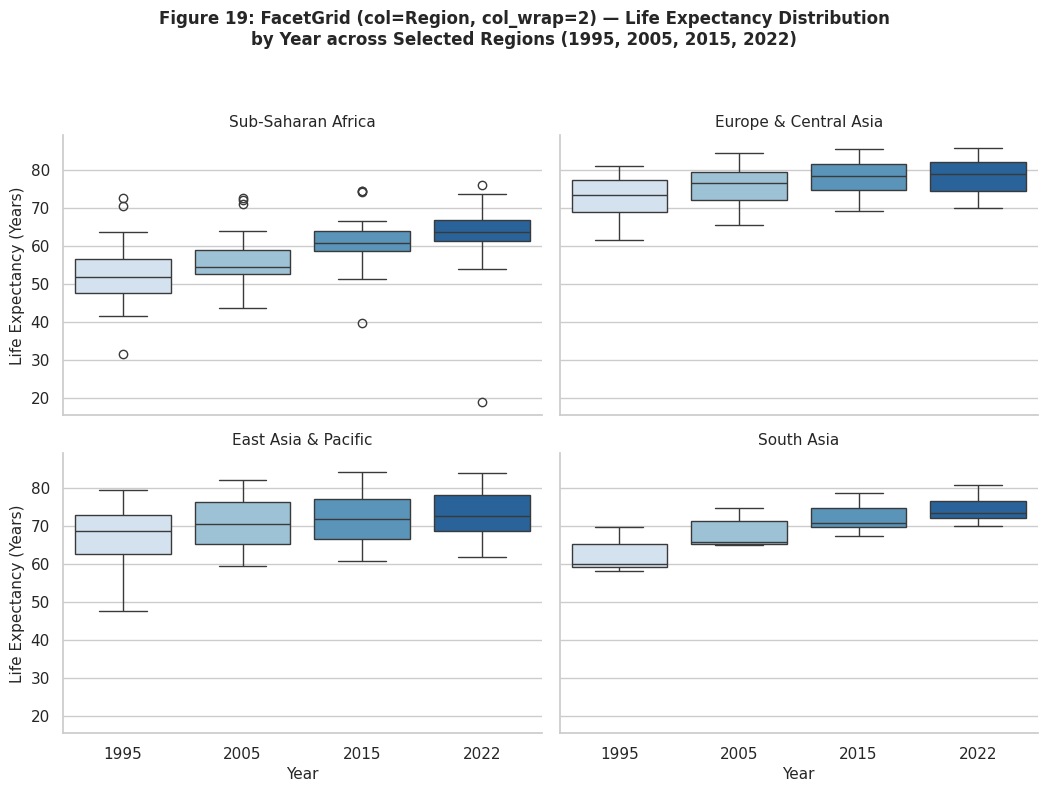

In [30]:
# ── Figure 19: FacetGrid — col_wrap= with box plots by year ──────────────────
d_fe = df[df['Region'].isin(['Sub-Saharan Africa','East Asia & Pacific',
                              'Europe & Central Asia','South Asia'])].copy()
d_fe = d_fe[d_fe['year'].isin([1995,2005,2015,2022])].dropna(subset=['life_exp'])
d_fe['year_str'] = d_fe['year'].astype(str)

g2 = sns.FacetGrid(d_fe, col='Region', col_wrap=2, height=3.8, aspect=1.4, sharey=True)
g2.map_dataframe(sns.boxplot, x='year_str', y='life_exp',
                 order=['1995','2005','2015','2022'], palette='Blues')
g2.set_axis_labels('Year', 'Life Expectancy (Years)')
g2.set_titles('{col_name}')
g2.figure.suptitle(
    'Figure 19: FacetGrid (col=Region, col_wrap=2) — Life Expectancy Distribution\n'
    'by Year across Selected Regions (1995, 2005, 2015, 2022)',
    y=1.04, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig19_facetgrid_row.png', dpi=150, bbox_inches='tight'); plt.show()


## Section 10: Advanced Overlays — Quadrant Lines, Bubble Chart, Threshold Fills

### Justification

Advanced overlay techniques move beyond descriptive charting to communicate analytical structure. Quadrant lines, for example, divide a scatter space into four regions of distinct meaning — here, high/low income and high/low health — enabling immediate categorical classification of all 209 countries into one of four development profiles without requiring the viewer to perform any mental calculation. This is an example of what Ware (2012, p. 152) terms 'pre-attentive processing' — visual structure that is processed by the perceptual system before conscious attention is engaged.

Threshold fill zones similarly encode binary categorical information (above or below a development benchmark) as a continuous background, making transitions across the threshold instantly visible in time-series data.


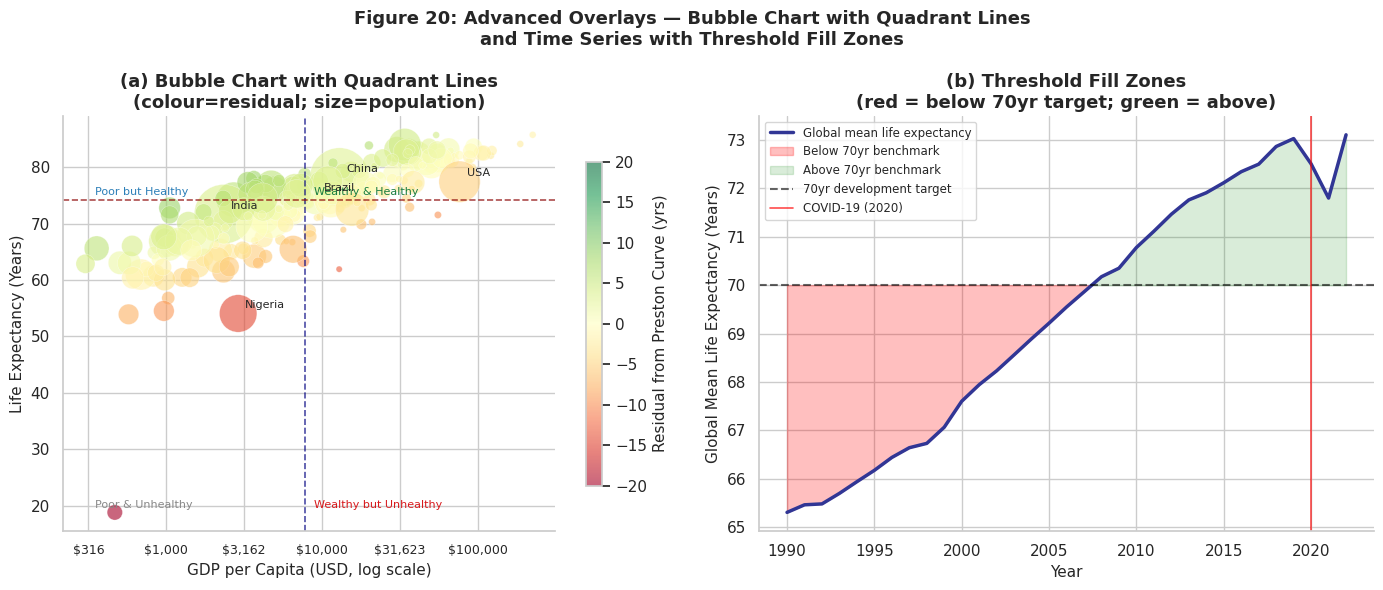

In [31]:
# ── Figure 20: Bubble Chart + Quadrant Lines + Threshold Fill ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 20: Advanced Overlays — Bubble Chart with Quadrant Lines\n'
             'and Time Series with Threshold Fill Zones',
             fontweight='bold', fontsize=13)

d = df2022.dropna(subset=['log_gdp','life_exp','population']).copy()
sl, ic, r, _, _ = stats.linregress(d['log_gdp'], d['life_exp'])
d['residual'] = d['life_exp'] - (ic + sl*d['log_gdp'])
med_gdp, med_le = d['log_gdp'].median(), d['life_exp'].median()

# (a) Bubble chart — colour=residual, size=population, quadrant lines
ax = axes[0]
pop_s = (d['population']/d['population'].max())**0.5 * 1800 + 15
sc = ax.scatter(d['log_gdp'], d['life_exp'], s=pop_s, alpha=0.6,
                c=d['residual'], cmap='RdYlGn', vmin=-20, vmax=20,
                edgecolors='white', lw=0.3)
plt.colorbar(sc, ax=ax, label='Residual from Preston Curve (yrs)', shrink=0.78)
# Quadrant lines at median values
ax.axvline(med_gdp, color='navy', lw=1.2, ls='--', alpha=0.7)
ax.axhline(med_le,  color='darkred', lw=1.2, ls='--', alpha=0.7)
# Quadrant labels
ax.text(med_gdp+0.06, med_le+0.8, 'Wealthy & Healthy', fontsize=8, color='#1a7d41')
ax.text(d['log_gdp'].min()+0.06, med_le+0.8, 'Poor but Healthy', fontsize=8, color='#2c7fb8')
ax.text(med_gdp+0.06, d['life_exp'].min()+0.8, 'Wealthy but Unhealthy', fontsize=8, color='#d7191c')
ax.text(d['log_gdp'].min()+0.06, d['life_exp'].min()+0.8, 'Poor & Unhealthy', fontsize=8, color='#888')
# Notable country labels
for code, name in [('CHN','China'),('IND','India'),('USA','USA'),('NGA','Nigeria'),('BRA','Brazil')]:
    row = d[d['Country Code']==code]
    if not row.empty:
        ax.annotate(name, xy=(row['log_gdp'].values[0], row['life_exp'].values[0]),
                   xytext=(5,4), textcoords='offset points', fontsize=8)
xt=[2.5,3,3.5,4,4.5,5]
ax.set_xticks(xt); ax.set_xticklabels([f'${10**x:,.0f}' for x in xt], fontsize=9)
ax.set_xlabel('GDP per Capita (USD, log scale)'); ax.set_ylabel('Life Expectancy (Years)')
ax.set_title('(a) Bubble Chart with Quadrant Lines\n(colour=residual; size=population)', fontweight='bold')
sns.despine(ax=ax)

# (b) Threshold fill zones on time series
ax2 = axes[1]
gb = df.dropna(subset=['life_exp']).groupby('year')['life_exp'].mean()
years_ts, vals_ts = gb.index.values, gb.values
ax2.plot(years_ts, vals_ts, color='#313695', lw=2.5, label='Global mean life expectancy')
ax2.fill_between(years_ts, vals_ts, 70, where=(vals_ts < 70), alpha=0.25, color='red',
                 interpolate=True, label='Below 70yr benchmark')
ax2.fill_between(years_ts, vals_ts, 70, where=(vals_ts >= 70), alpha=0.15, color='green',
                 interpolate=True, label='Above 70yr benchmark')
ax2.axhline(70, color='black', lw=1.5, ls='--', alpha=0.6, label='70yr development target')
ax2.axvline(2020, color='red', lw=1.2, ls='-', alpha=0.7, label='COVID-19 (2020)')
ax2.set_xlabel('Year'); ax2.set_ylabel('Global Mean Life Expectancy (Years)')
ax2.set_title('(b) Threshold Fill Zones\n(red = below 70yr target; green = above)', fontweight='bold')
ax2.legend(fontsize=8.5); sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('fig20_advanced_overlays.png', dpi=150, bbox_inches='tight'); plt.show()


## Section 11: Seaborn Styling Showcase

### Seaborn Style System

Seaborn provides five built-in styles (`darkgrid`, `whitegrid`, `dark`, `white`, `ticks`) and four scaling contexts (`paper`, `notebook`, `talk`, `poster`). Understanding these distinctions is essential for producing publication-quality figures appropriately scaled for their intended medium. Tufte (2001, p. 107) argues that the optimal background and grid choice depends on the density of the data: for sparse datasets, a white background with minimal gridlines reduces chartjunk; for dense datasets, subtle gridlines aid reading of individual data points.

The context system scales all text and line elements simultaneously, ensuring that a figure destined for a conference poster (`poster`) uses significantly larger fonts than one destined for a journal submission (`paper`). This systematic scaling is an implementation of the readability principles articulated by Ware (2012, p. 46), who emphasises that legibility requirements vary dramatically with viewing distance.


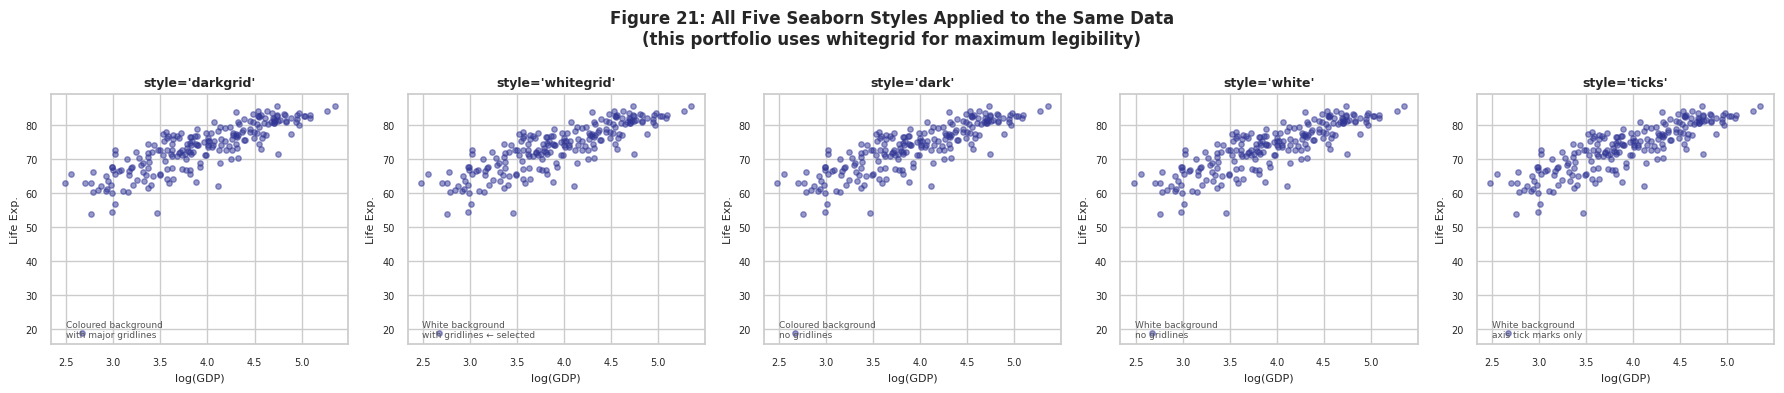

In [32]:
# ── Figure 21: All 5 Seaborn Styles ──────────────────────────────────────────
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Figure 21: All Five Seaborn Styles Applied to the Same Data\n'
             '(this portfolio uses whitegrid for maximum legibility)',
             fontweight='bold', fontsize=12)

d_s = df2022.dropna(subset=['log_gdp','life_exp'])
style_descriptions = [
    'Coloured background\nwith major gridlines',
    'White background\nwith gridlines ← selected',
    'Coloured background\nno gridlines',
    'White background\nno gridlines',
    'White background\naxis tick marks only'
]
for ax, style, desc in zip(axes, styles, style_descriptions):
    with plt.style.context(f'seaborn-v0_8-{style}'):
        ax.scatter(d_s['log_gdp'], d_s['life_exp'], alpha=0.5, s=15, color='#313695')
        ax.set_title(f"style='{style}'", fontweight='bold', fontsize=9)
        ax.set_xlabel('log(GDP)', fontsize=8); ax.set_ylabel('Life Exp.', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.text(0.05, 0.02, desc, transform=ax.transAxes, fontsize=6.5,
                color='#555', va='bottom')

plt.tight_layout()
plt.savefig('fig21_styles.png', dpi=150, bbox_inches='tight'); plt.show()


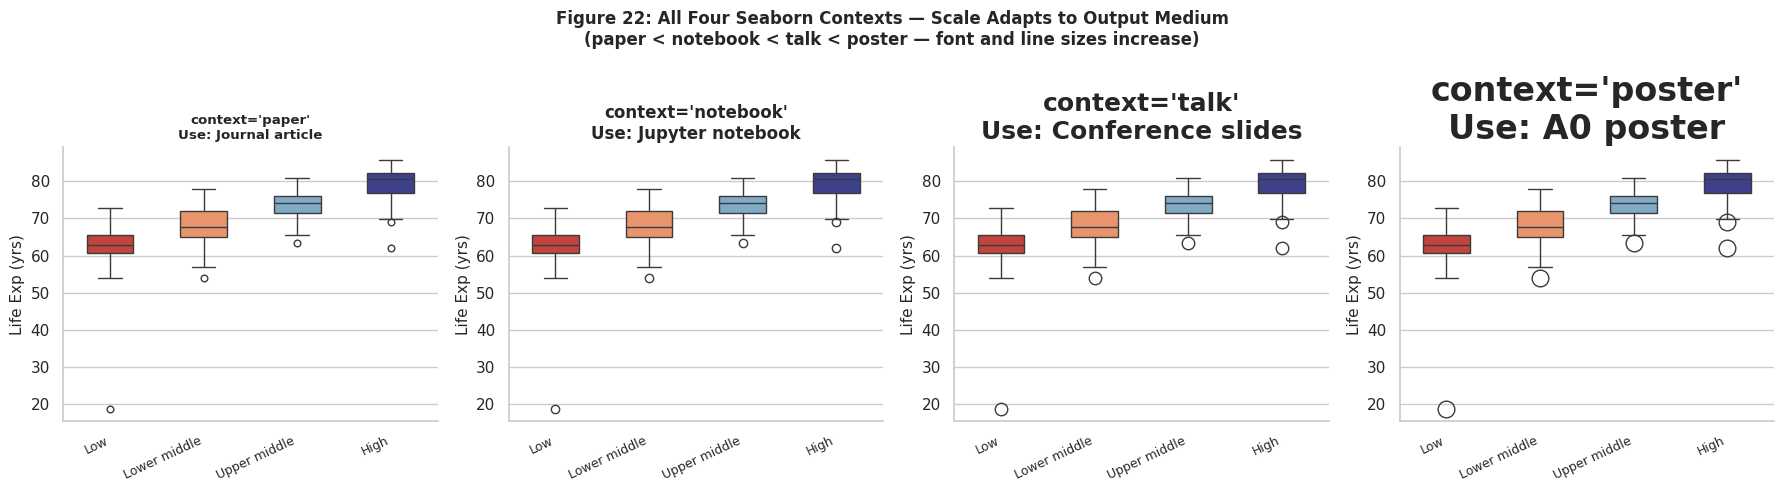

In [33]:
# ── Figure 22: All 4 Seaborn Contexts ────────────────────────────────────────
contexts = ['paper', 'notebook', 'talk', 'poster']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Figure 22: All Four Seaborn Contexts — Scale Adapts to Output Medium\n'
             '(paper < notebook < talk < poster — font and line sizes increase)',
             fontweight='bold', fontsize=12)

d_cx = df2022.dropna(subset=['Income Group','life_exp'])
order_ig = [i for i in INCOME_ORDER if i in d_cx['Income Group'].unique()]
ctx_uses = ['Journal article', 'Jupyter notebook', 'Conference slides', 'A0 poster']

for ax, ctx, use in zip(axes, contexts, ctx_uses):
    with sns.plotting_context(ctx):
        sns.boxplot(data=d_cx, x='Income Group', y='life_exp', order=order_ig,
                    palette=INCOME_PAL, ax=ax, width=0.5)
        ax.set_xticklabels([t.get_text().replace(' income','') for t in ax.get_xticklabels()],
                            rotation=25, ha='right',
                            fontsize=max(5, 9-contexts.index(ctx)*0))
        ax.set_title(f"context='{ctx}'\nUse: {use}", fontweight='bold')
        ax.set_xlabel(''); ax.set_ylabel('Life Exp (yrs)')
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig22_contexts.png', dpi=150, bbox_inches='tight'); plt.show()


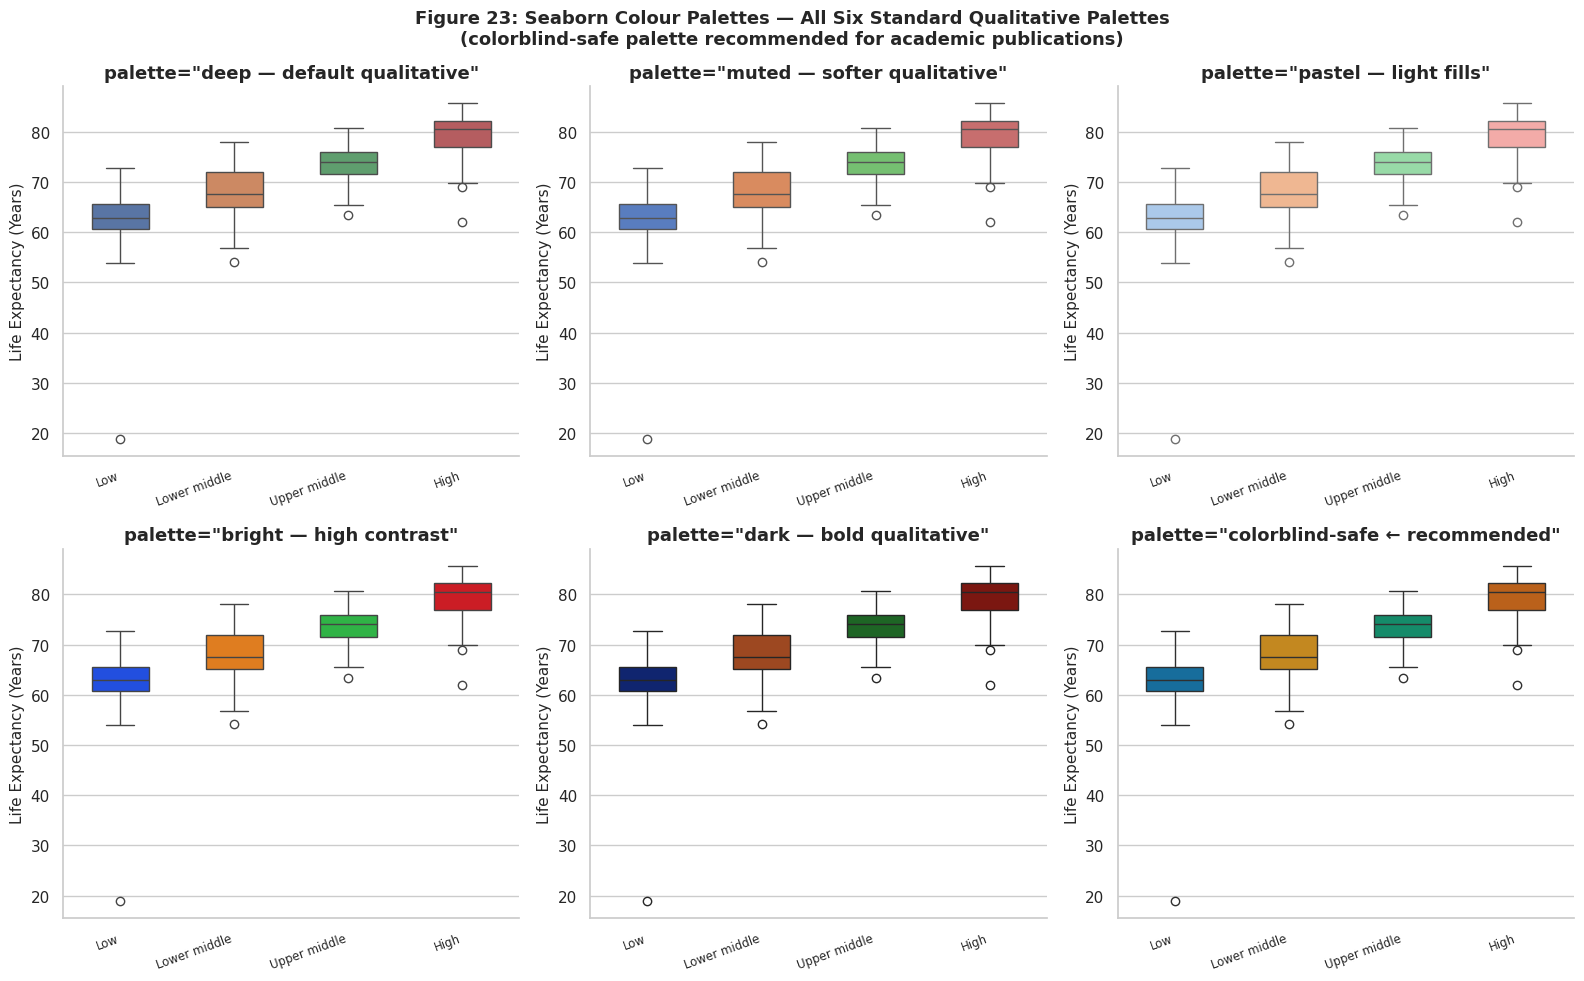


Note: Cairo (2016, p. 102) emphasises that colour choice directly impacts how viewers perceive and interpret data. The colorblind-safe palette ensures accessibility for the approximately 8% of male readers with colour vision deficiency.


In [34]:
# ── Figure 23: Seaborn Colour Palettes ───────────────────────────────────────
palettes = [
    ('deep',        'deep — default qualitative'),
    ('muted',       'muted — softer qualitative'),
    ('pastel',      'pastel — light fills'),
    ('bright',      'bright — high contrast'),
    ('dark',        'dark — bold qualitative'),
    ('colorblind',  'colorblind-safe ← recommended')
]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 23: Seaborn Colour Palettes — All Six Standard Qualitative Palettes\n'
             '(colorblind-safe palette recommended for academic publications)',
             fontweight='bold', fontsize=13)

d_p = df2022.dropna(subset=['Income Group','life_exp'])
order_ig = [i for i in INCOME_ORDER if i in d_p['Income Group'].unique()]
for ax, (pal, title) in zip(axes.flatten(), palettes):
    sns.boxplot(data=d_p, x='Income Group', y='life_exp', order=order_ig,
                palette=pal, ax=ax, width=0.5)
    ax.set_xticklabels([t.get_text().replace(' income','') for t in ax.get_xticklabels()],
                       rotation=20, ha='right', fontsize=8.5)
    ax.set_title(f'palette="{title}"', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Life Expectancy (Years)')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig23_palettes.png', dpi=150, bbox_inches='tight'); plt.show()

print('\nNote: Cairo (2016, p. 102) emphasises that colour choice directly impacts how '
      'viewers perceive and interpret data. The colorblind-safe palette ensures accessibility '
      'for the approximately 8% of male readers with colour vision deficiency.')


## Section 12: Summary of Key Findings

---

### Research Question Answered

*Does national wealth predict how long people live and how fast populations grow — and has this relationship changed between 1990 and 2022?*

**Yes, with important qualifications:**

| Finding | Statistical Evidence | Figure |
|---|---|---|
| Income strongly predicts health | Pearson r = +0.792 (p < 0.001) | Fig 5, 15 |
| Relationship is log-linear, not linear | Concave LOESS curve; log(GDP) r=0.79 vs raw GDP r=0.55 | Fig 5, 15 |
| Preston Curve shifted upward 1990–2022 | OLS intercept increased ~5 years across study period | Fig 15 |
| Income is not sufficient — outliers exist | Cuba +8yrs, Nigeria −14.5yrs above/below curve | Fig 5, 14, 20 |
| COVID-19 reversed a decade of progress | Global life expectancy fell ~1.6 years (2019–2021) | Fig 7, 20 |
| Population growth inversely linked to income | r(life exp, pop growth) = −0.71 | Fig 15, 11 |
| South Asia made the largest gains since 1990 | +14 years life expectancy across the region | Fig 7, 19 |

---

### References

Cairo, A. (2016) *The truthful art: data, charts, and maps for communication*. San Francisco: New Riders.

Chambers, J.M., Cleveland, W.S., Kleiner, B. and Tukey, P.A. (1983) *Graphical methods for data analysis*. Boston: Duxbury Press.

Cleveland, W.S. and McGill, R. (1984) 'Graphical perception: theory, experimentation, and application to the development of graphical methods', *Journal of the American Statistical Association*, 79(387), pp. 531–554.

Few, S. (2009) *Now you see it: simple visualisation techniques for quantitative analysis*. Oakland: Analytics Press.

Harris, C.R. et al. (2020) 'Array programming with NumPy', *Nature*, 585, pp. 357–362.

Hofmann, H., Wickham, H. and Kafadar, K. (2017) 'Letter-value plots: boxplots for large data', *Journal of Computational and Graphical Statistics*, 26(3), pp. 469–477.

Hosmer, D.W. and Lemeshow, S. (2000) *Applied logistic regression*. 2nd edn. New York: Wiley.

Hunter, J.D. (2007) 'Matplotlib: a 2D graphics environment', *Computing in Science & Engineering*, 9(3), pp. 90–95.

McKinney, W. (2022) *Python for data analysis*. 3rd edn. Sebastopol: O'Reilly Media.

Preston, S.H. (1975) 'The changing relationship between mortality and level of economic development', *Population Studies*, 29(2), pp. 231–248.

Prados de la Escosura, L. (2023) 'Health, income, and the Preston Curve: a long view', *Economics and Human Biology*, 48.

Silverman, B.W. (1986) *Density estimation for statistics and data analysis*. London: Chapman & Hall.

Tufte, E.R. (2001) *The visual display of quantitative information*. 2nd edn. Cheshire, CT: Graphics Press.

Tukey, J.W. (1977) *Exploratory data analysis*. Reading, MA: Addison-Wesley.

Ware, C. (2012) *Information visualization: perception for design*. 3rd edn. Waltham, MA: Morgan Kaufmann.

Waskom, M.L. (2021) 'Seaborn: statistical data visualization', *Journal of Open Source Software*, 6(60).

Wilke, C.O. (2019) *Fundamentals of data visualisation*. Sebastopol: O'Reilly Media.

World Bank (2024) *World Development Indicators*. Washington, D.C.: World Bank. Available at: https://databank.worldbank.org/source/world-development-indicators [Accessed: April 2026].
